In [20]:
def mean_ratio_markers(pb: pd.DataFrame, topk_per_ct: int, ct_order: list[str],
                       pseudocount: float = 1e-9, min_cols_per_ct: int = 1) -> list[str]:
    """
    Mean Ratio 選標法（每型 Top-K）：
      score_g,ct = ( mean_expr_g_in_ct + eps ) / ( max_{ct'!=ct} mean_expr_g_in_ct' + eps )
    參數
      pb: pseudobulk 矩陣（genes × columns），columns 形如 "Sample|CellType"
      topk_per_ct: 每個 cell type 挑 Top-K 基因
      ct_order: 想要的 cell type 順序（缺的會自動忽略，多的會追加在後）
      pseudocount: 避免 0 的微小常數
      min_cols_per_ct: 每個 cell type 至少需要的欄數（不足則跳過）
    回傳
      markers（list[str]）
    """
    # 解析出所有 cell types
    ct_all = sorted({c.split("|", 1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in ct_all] + [ct for ct in ct_all if ct not in ct_order]

    # 預先算：每個 cell type 的「基因×該型平均表達」
    mean_by_ct = {}
    for ct in ct_all:
        cols = [c for c in pb.columns if c.split("|", 1)[1] == ct]
        if len(cols) >= min_cols_per_ct:
            mean_by_ct[ct] = pb[cols].mean(axis=1)
    # 如果不足兩個 cell type 有平均值，就回傳空
    if len(mean_by_ct) < 2:
        return []

    sel = set()
    for ct in order:
        if ct not in mean_by_ct:
            continue
        m_ct = mean_by_ct[ct]

        # 其他 cell type 的平均表達 -> 逐基因取最大值
        others = [v for k, v in mean_by_ct.items() if k != ct]
        m_other_max = pd.concat(others, axis=1).max(axis=1)

        # Mean Ratio 分數（越大越專一）
        score = (m_ct + pseudocount) / (m_other_max + pseudocount)
        score = score.sort_values(ascending=False)

        sel.update(score.index[:topk_per_ct])

    return list(sel)


In [ ]:
def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: list[str]) -> list[str]:
    """Per-CT marker selection with logFC."""
    cts = sorted({c.split("|", 1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]

    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()

    for ct in order:
        cols = [c for c in pb.columns if c.split("|", 1)[1] == ct]
        if not cols:
            continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1, (len(cts) - 1))
        score = np.log2((m_ct + 1e-9) / (rest + 1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])

    return list(sel)

In [9]:
# === 依 CT 內做共線刪減（pearson 相關）===
def prune_correlated_markers(pb: pd.DataFrame,
                             markers_by_ct: dict[str, list[str]],
                             pval_df: pd.DataFrame | None = None,
                             lfc_ref: pd.DataFrame | None = None,
                             corr_thr: float = 0.90,
                             method: str = "pearson") -> dict[str, list[str]]:
    """
    pb: genes × (Sample|CT)（建議 asinh+ComBat 之後）
    markers_by_ct: {ct: [genes]}（你的 markers_combined_by_ct）
    pval_df: genes×CT 的 p 值表（可選，用來當排序分數的一部分）
    lfc_ref: genes×CT 的 log2FC（可選；若無則用 pb 的該 CT 均值當 proxy）
    corr_thr: 同 CT 內的相關門檻（>= 此值會被視為共線）
    method: 'pearson' or 'spearman'
    """
    pruned = {}
    tags = [c.split("|",1)[1] for c in pb.columns]

    # 小工具：取該 CT 的所有 Sample 欄
    def ct_cols(ct):
        return [c for c,t in zip(pb.columns, tags) if t==ct]

    # 小工具：決定排序分數（優先高 log2FC，其次 -log10 p）
    def rank_score(genes, ct):
        import numpy as np, pandas as pd
        s = pd.Series(0.0, index=genes, dtype=float)
        if lfc_ref is not None and ct in lfc_ref.columns:
            s = s.add(lfc_ref.loc[genes, ct].fillna(0.0), fill_value=0.0)
        else:
            # 沒有 lfc 時，用該 CT 均值當 proxy（較粗糙）
            cols = ct_cols(ct)
            if cols:
                s = s.add(pb.loc[genes, cols].mean(axis=1).fillna(0.0), fill_value=0.0)
        if pval_df is not None and ct in pval_df.columns:
            add = (-np.log10(pval_df.loc[genes, ct].replace(0, np.nan))).fillna(0.0)
            s = s.add(add, fill_value=0.0)
        return s.sort_values(ascending=False)

    for ct, genes in markers_by_ct.items():
        genes = [g for g in genes if g in pb.index]
        if len(genes) <= 1:
            pruned[ct] = genes
            continue

        cols = ct_cols(ct)
        if len(cols) < 2:  # 該 CT 樣本太少，跳過剪枝
            pruned[ct] = genes
            continue

        # 先按分數排序（高分優先保留）
        order = rank_score(genes, ct).index.tolist()

        keep = []
        # 用已保留的基因與候選做相關檢查（貪婪）
        for g in order:
            if not keep:
                keep.append(g); continue
            # 與 keep 中所有基因在該 CT 樣本上的相關
            x = pb.loc[g, cols].astype(float).values
            # 只要任一相關 >= 門檻就捨棄
            redundant = False
            for k in keep:
                y = pb.loc[k, cols].astype(float).values
                if method == "spearman":
                    from scipy.stats import spearmanr
                    r, _ = spearmanr(x, y, nan_policy="omit")
                else:
                    # pearson
                    vx = x - np.nanmean(x); vy = y - np.nanmean(y)
                    r = np.nansum(vx*vy) / (np.sqrt(np.nansum(vx*vx))*np.sqrt(np.nansum(vy*vy)) + 1e-12)
                if np.isfinite(r) and abs(r) >= corr_thr:
                    redundant = True
                    break
            if not redundant:
                keep.append(g)

        pruned[ct] = keep

    return pruned


[Prune] 剪枝前/後基因數：5931 → 766
  T            : 2745 → 168
  B            : 2745 → 162
  NK           : 10 → 10
  Plasmablast  : 14 → 14
  Endothelial  : 2974 → 161
  Fibroblast   : 40 → 29
  Myofibroblast: 2974 → 160
  Myeloid      : 141 → 59
  Mast         : 43 → 35


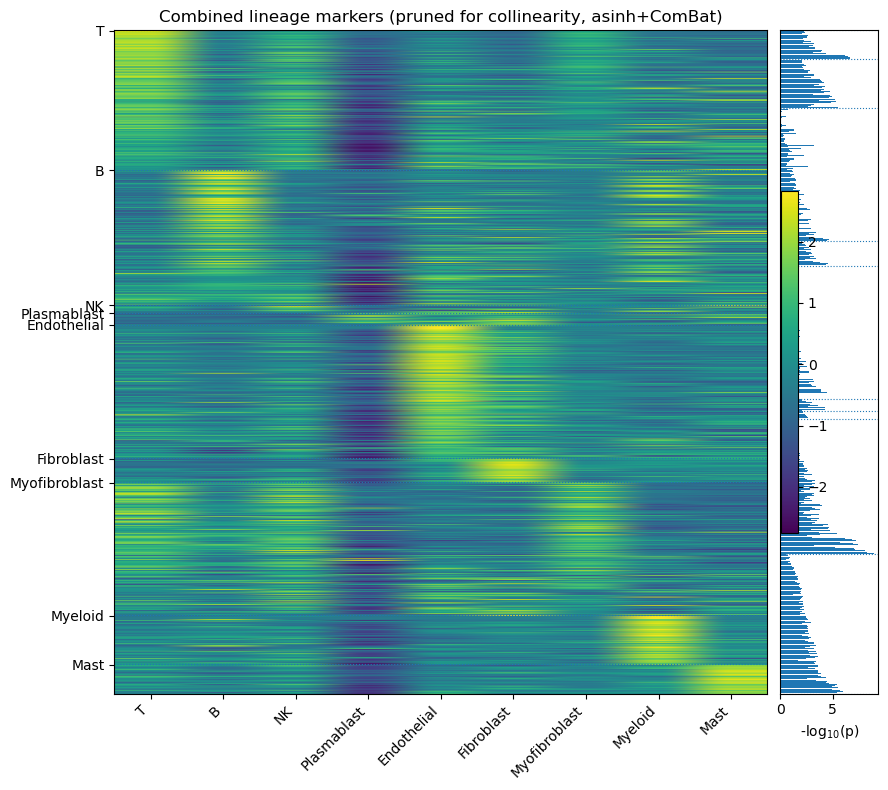

淋巴候選（穩定）基因數: 5489
非淋巴候選（穩定）基因數: 5947
每個 CT 實際選入的基因數：
  T            : 2745
  B            : 2745
  NK           : 10
  Plasmablast  : 14
  Endothelial  : 2974
  Fibroblast   : 40
  Myofibroblast: 2974
  Myeloid      : 141
  Mast         : 43


In [13]:
# Jupyter cell: Joint-preproc bulk (train+test, no PCA) + LOPO(inner K) Ridge(ILR)
# Strategy: ilr_inv-per-fold → mean in simplex
from __future__ import annotations
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, random, warnings
warnings.filterwarnings("ignore")

# ===== PATHS =====
AD_TRAIN_PATH   = r"../train_data/train_adata.h5ad"

# ===== SETTINGS =====
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]

# ===== utils =====
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.normalize_total(ad, target_sum=1e4)
    sc.pp.log1p(ad)

import numpy as np
import pandas as pd

def pseudobulk_by_sample_ct(
    ad,
    ct_col: str,
    sample_col: str,
    transform: str = "asinh",   # "asinh" | "log1p" | None
    asinh_c: float = 1.0,       # arcsinh(x / c) 的 c；常用 1.0 或 5.0
    use_layer: str | None = None  # 若你的 AnnData 有 raw counts 層，可指定如 "counts"
) -> pd.DataFrame:
    """
    1) 從單細胞回線性尺度（優先用指定 layer 或 ad.layers['counts']，否則 expm1(ad.X)）
    2) 依 (Sample, CT) 對細胞取平均 → 得到 pseudobulk（線性平均）
    3) 依 transform 做變異穩定化：asinh(x/c) 或 log1p(x)
    回傳：genes × (Sample|CT) 的 DataFrame
    """
    # --- 1) 回到線性尺度 ---
    if use_layer is not None and use_layer in ad.layers:
        X_linear = ad.layers[use_layer]
    elif "counts" in getattr(ad, "layers", {}):
        X_linear = ad.layers["counts"]
    else:
        # 你的 preprocess_sc 做了 log1p(ad)，用 expm1 還原
        X_linear = ad.X
        if hasattr(X_linear, "A"):   # scipy.sparse
            X_linear = X_linear.A
        X_linear = np.expm1(np.asarray(X_linear))

    # --- 2) 依 Sample×CT 平均（線性平均）---
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = X_linear[idx]
        # 稀疏/稠密都支援
        if hasattr(Xi, "mean"):  # numpy array
            avg = np.asarray(Xi.mean(axis=0)).ravel()
        else:                    # 稀疏矩陣切片
            avg = np.asarray(Xi.mean(axis=0)).ravel()
        cols.append(avg); names.append(f"{s}|{ct}")

    pb = pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

    # --- 3) 變異穩定化 ---
    if transform is None:
        return pb
    elif transform.lower() == "log1p":
        return np.log1p(pb)
    elif transform.lower() == "asinh":
        # asinh(x / c)，c 控制在低表達區域的近似線性段；c 越大，壓縮越弱
        c = float(asinh_c) if asinh_c is not None else 1.0
        return np.arcsinh(pb / c)
    else:
        raise ValueError("transform must be one of {'asinh','log1p',None}")


def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch = Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: list[str]) -> list[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm10k(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0).astype(float); lib[lib==0.0] = 1.0
    return df.div(lib, axis=1) * 1e4

# ===== load =====
sc = need_scanpy()
ad_tr = need_scanpy().read_h5ad(AD_TRAIN_PATH)


# train sc preprocess（只用它選 marker）
preprocess_sc(ad_tr)

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import ttest_ind


# 1) 從單細胞做 pseudobulk（Sample|CT）→ ComBat (batch=Sample)
pb_all = pseudobulk_by_sample_ct(
    ad_tr,
    ct_col=CELLTYPE_COL,
    sample_col="Sample",
    transform="asinh",
    asinh_c=1.0,        # 可試 1.0 / 5.0 / 10.0
    use_layer=None      # 若有 ad.layers["counts"]，可設 "counts"
)

pb_all = combat_on_pb(pb_all)                                     # ComBat 校正

# 2) 聚合到 (Patient|CT)：同病人同 CT 的 sample 取均值
def mean_by_patient_ct(pb: pd.DataFrame) -> pd.DataFrame:
    pats = [c.split("|",1)[0] for c in pb.columns]
    cts  = [c.split("|",1)[1] for c in pb.columns]
    meta = pd.DataFrame({"patient": pats, "ct": cts}, index=pb.columns)
    groups = meta.groupby(["patient","ct"]).groups
    cols_out = []
    for (p, ct), idx in groups.items():
        cols = list(idx)
        col_mean = pb.loc[:, cols].mean(axis=1)
        col_mean.name = f"{p}|{ct}"
        cols_out.append(col_mean)
    if len(cols_out)==0:
        raise ValueError("沒有可用的 (Patient|CT) 聚合結果，請檢查單細胞的 Sample/Patient 標註。")
    return pd.concat(cols_out, axis=1)  # genes × (Patient|CT)

pb_pat = mean_by_patient_ct(pb_all)  # genes × (Patient|CT)

# 3) 以「中度表達 + 低 CoV」挑穩定基因（每個 CT 一個 mask）
def stable_gene_mask_by_ct(pb_pat: pd.DataFrame,
                           ct: str,
                           expr_quant=(0.3, 0.9),
                           cov_q=0.7) -> pd.Series:
    ct_cols = [c for c in pb_pat.columns if c.split("|",1)[1]==ct]
    if len(ct_cols) < 2:
        return pd.Series(False, index=pb_pat.index)
    M = pb_pat[ct_cols]
    mu = M.mean(axis=1).abs() + 1e-9
    sd = M.std(axis=1)
    cov = (sd / mu).fillna(0.0)
    lo, hi = mu.quantile(expr_quant[0]), mu.quantile(expr_quant[1])
    expr_ok = (mu >= lo) & (mu <= hi)
    cov_thr = cov.quantile(cov_q)
    cov_ok  = cov <= cov_thr
    return (expr_ok & cov_ok)

# 4) 子空間定義與「壞基因」過濾（免疫球蛋白/TCR 可變區）
LYMPH_SET = {"T","B","NK","Plasmablast"}
NONLY_SET = {"Endothelial","Fibroblast","Myofibroblast","Myeloid","Mast"}
BAD_PREFIX = ("IGH","IGK","IGL","TRB","TRA","TRG","TRD")

# 5) 先挑「穩定集合」：每個 CT 的穩定基因 union 起來（分淋巴/非淋巴兩組）
stable_by_ct = {}
for ct in sorted({c.split("|",1)[1] for c in pb_pat.columns}):
    mask = stable_gene_mask_by_ct(pb_pat, ct, expr_quant=(0.3,0.9), cov_q=0.7)
    gs = pb_pat.index[mask].tolist()
    gs = [g for g in gs if not str(g).upper().startswith(BAD_PREFIX)]
    stable_by_ct[ct] = gs

stable_lymph = sorted({g for ct,gs in stable_by_ct.items() if ct in LYMPH_SET for g in gs})
stable_non   = sorted({g for ct,gs in stable_by_ct.items() if ct in NONLY_SET for g in gs})

# 6) 在各自子空間內做排名（log2FC + Welch p），並用「自動門檻」決定保留數量（不是固定 top-K）
def mean_by_ct(pb: pd.DataFrame) -> pd.DataFrame:
    tags = [c.split("|",1)[1] for c in pb.columns]
    out={}
    for ct in sorted(set(tags)):
        cols = [c for c,t in zip(pb.columns, tags) if t==ct]
        if cols: out[ct] = pb[cols].mean(axis=1)
    return pd.DataFrame(out)  # genes × CT
from typing import Tuple, Dict
import numpy as np
import pandas as pd
from math import ceil
from scipy.stats import ttest_ind

def _bh_fdr(p: pd.Series) -> pd.Series:
    """Benjamini–Hochberg FDR（不依賴 statsmodels），對單一向量做校正。"""
    p = p.astype(float).fillna(1.0).clip(0,1)
    n = p.shape[0]
    order = np.argsort(p.values)
    ranked = p.values[order]
    q = ranked * n / (np.arange(n) + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out = np.empty_like(q)
    out[:] = q
    q_series = pd.Series(out, index=p.index[order])
    return q_series.reindex(p.index)

def score_and_select(pb: pd.DataFrame,
                     candidate_genes: list[str],
                     ct_set: set[str],
                     lfc_min: float = 0.5,
                     alpha: float = 0.01,
                     quant_cap: float = 0.5,
                     # —— 新增：專一性與 FDR 選項 ——
                     enforce_exclusive: bool = True,
                     alpha_other: float = 0.05,
                     margin_other: float = 0.2,
                     use_fdr: bool = True
                     ) -> Tuple[Dict[str, list[str]], pd.DataFrame, pd.DataFrame]:
    """
    對 candidate_genes 在 ct_set 內：
      - 算每個 CT 的 log2FC（該CT均值 vs 其它CT均值）
      - Welch t-test 做 p 值（可選 FDR）
      - 『專一性』選取（若 enforce_exclusive=True）：
          1) 在目標 CT 上顯著：p(or q) < alpha 且 log2FC > lfc_min
          2) 對其它 CT 不顯著：p(or q) >= alpha_other
          3) 目標 CT 的 log2FC 至少比其它 CT 高 margin_other
        若這樣選太少，會 fallback：補到該 CT 的前 quant_cap 分位數（按 score 排）
    回傳： (per-CT gene list, p(or q)表 genes×CT, lfc表 genes×CT)
    """
    # 只保留子空間欄
    keep_cols = [c for c in pb.columns if c.split("|",1)[1] in ct_set]
    sub = pb[keep_cols]
    cts = sorted(ct_set.intersection({c.split("|",1)[1] for c in sub.columns}))
    if len(cts) < 2 or len(candidate_genes) == 0:
        return {ct: [] for ct in ct_set}, pd.DataFrame(index=candidate_genes, columns=list(ct_set)), pd.DataFrame(index=candidate_genes, columns=list(ct_set))

    # ——— p 值（Welch）———
    tags = [c.split("|",1)[1] for c in sub.columns]
    p_df = {}
    for ct in cts:
        in_cols  = [c for c,t in zip(sub.columns, tags) if t==ct]
        out_cols = [c for c,t in zip(sub.columns, tags) if t!=ct]
        ps = []
        for g in candidate_genes:
            if g in sub.index:
                a = sub.loc[g, in_cols].astype(float).values
                b = sub.loc[g, out_cols].astype(float).values
            else:
                a = np.array([np.nan]); b = np.array([np.nan])
            if (np.sum(~np.isnan(a))>=2) and (np.sum(~np.isnan(b))>=2):
                _, pv = ttest_ind(a, b, equal_var=False, nan_policy="omit")
            else:
                pv = np.nan
            ps.append(pv)
        p_df[ct] = pd.Series(ps, index=candidate_genes)
    p_df = pd.DataFrame(p_df)

    # 可選：FDR（BH）
    if use_fdr:
        q_df = pd.DataFrame({ct: _bh_fdr(p_df[ct]) for ct in cts})
        p_used = q_df  # 用 q 當判斷顯著
    else:
        q_df = p_df.copy()
        p_used = p_df

    # ——— log2FC（one-vs-rest）———
    # 每 CT 均值
    out_mean = {}
    for ct in cts:
        cols = [c for c,t in zip(sub.columns, tags) if t==ct]
        if cols:
            out_mean[ct] = sub[cols].mean(axis=1)
    Mct = pd.DataFrame(out_mean).reindex(index=candidate_genes)
    mean_all = Mct.mean(axis=1) + 1e-9
    lfc = {}
    for ct in cts:
        m_ct = (Mct[ct] + 1e-9)
        rest = (mean_all*len(cts) - m_ct) / max(1, len(cts)-1) + 1e-9
        lfc[ct] = np.log2(m_ct / rest)
    lfc = pd.DataFrame(lfc).reindex(index=candidate_genes)

    # ——— 專一性選取 + fallback ———
    per_ct = {}
    # 為 fallback 準備一個綜合分數（大者佳）：log2FC × (-log10 p)
    with np.errstate(divide='ignore'):
        neglogp = -np.log10(p_used.clip(lower=1e-300))
    comp_score = (lfc.clip(lower=0) * neglogp.fillna(0)).fillna(0)

    for ct in cts:
        # 核心條件（目標 CT 顯著 & fold-change 達標）
        core = (p_used[ct] < alpha) & (lfc[ct] > lfc_min)

        if enforce_exclusive:
            # 其它 CT 不顯著
            others_nsig = (p_used.drop(columns=[ct]) >= alpha_other).all(axis=1)
            # 與其它 CT 的 log2FC 差距
            lfc_gap = lfc[ct] - lfc.drop(columns=[ct]).max(axis=1)
            gap_ok = lfc_gap >= margin_other
            good = core & others_nsig & gap_ok
        else:
            good = core

        sel = lfc.index[good].tolist()

        # Fallback：太少則補前 quant_cap（按 comp_score 排）
        if len(sel) < 10:
            rank = comp_score[ct].sort_values(ascending=False)
            k = max(10, int(ceil(len(rank) * quant_cap)))
            sel = rank.index[:k].tolist()

        per_ct[ct] = sel

    # 把沒有出現在子空間的 CT 也補 key（空 list）
    for ct in (ct_set - set(cts)):
        per_ct[ct] = []

    return per_ct, (q_df if use_fdr else p_df), lfc


# 先在淋巴子空間內做（候選＝穩定淋巴）
# 先在淋巴子空間內做（候選＝穩定淋巴）
markers_lymph_by_ct, q_lymph, lfc_lymph = score_and_select(
    pb_all, stable_lymph, LYMPH_SET,
    lfc_min=0.5, alpha=0.01, quant_cap=0.5,
    enforce_exclusive=True, alpha_other=0.05, margin_other=0.2, use_fdr=True
)

# 再在非淋巴子空間做（候選＝穩定非淋巴）
markers_non_by_ct, q_non, lfc_non = score_and_select(
    pb_all, stable_non, NONLY_SET,
    lfc_min=0.5, alpha=0.01, quant_cap=0.5,
    enforce_exclusive=True, alpha_other=0.05, margin_other=0.2, use_fdr=True
)

# 合併 per-CT markers（剪枝前）
markers_combined_by_ct = {ct: [] for ct in (LYMPH_SET | NONLY_SET)}
for ct, gs in markers_lymph_by_ct.items():
    markers_combined_by_ct[ct] = list(dict.fromkeys(gs))
for ct, gs in markers_non_by_ct.items():
    markers_combined_by_ct[ct] = list(dict.fromkeys(markers_combined_by_ct.get(ct, []) + gs))

# union markers（剪枝前）
markers_union = sorted({g for gs in markers_combined_by_ct.values() for g in gs})

# p/q 表（畫 -log10 用）
p_all = pd.concat([q_lymph, q_non], axis=1)

# log2FC 表（剪枝排序用 + 想查分數也方便）
lfc_all = pd.concat([lfc_lymph, lfc_non], axis=1)


# 算一份 log2FC 供剪枝排序（如果你不想改 score_and_select 的回傳，這裡重算一次即可）
def compute_lfc_table(pb: pd.DataFrame, ct_set: set[str], gene_list: list[str]) -> pd.DataFrame:
    keep_cols = [c for c in pb.columns if c.split("|",1)[1] in ct_set]
    sub = pb[keep_cols]
    cts = sorted(ct_set.intersection({c.split("|",1)[1] for c in sub.columns}))
    if len(cts) < 2:
        return pd.DataFrame(index=gene_list, columns=list(ct_set))
    # 每 CT 均值
    tags = [c.split("|",1)[1] for c in sub.columns]
    out = {}
    for ct in cts:
        cols = [c for c,t in zip(sub.columns, tags) if t==ct]
        if cols:
            out[ct] = sub[cols].mean(axis=1)
    Mct = pd.DataFrame(out).reindex(index=gene_list)
    mean_all = Mct.mean(axis=1) + 1e-9
    lfc = {}
    for ct in cts:
        m_ct = Mct[ct] + 1e-9
        rest = (mean_all*len(cts) - m_ct) / max(1, len(cts)-1) + 1e-9
        lfc[ct] = np.log2(m_ct/rest)
    return pd.DataFrame(lfc).reindex(index=gene_list)

lfc_lymph = compute_lfc_table(pb_all, LYMPH_SET, markers_union)
lfc_non   = compute_lfc_table(pb_all, NONLY_SET, markers_union)
lfc_all   = pd.concat([lfc_lymph, lfc_non], axis=1)

# ---------- 👉 新增：在每個 CT 內剪除高度共線的基因 ----------
# 這裡用你已有的 prune_correlated_markers 函式
markers_pruned_by_ct = prune_correlated_markers(
    pb=pb_all,
    markers_by_ct=markers_combined_by_ct,  # 剪枝前的 per-CT markers
    pval_df=p_all,                          # 用來輔助排序（-log10 p 越大越優先保留）
    lfc_ref=lfc_all,                        # 用來輔助排序（log2FC 越大越優先保留）
    corr_thr=0.90,                          # 可試 0.85~0.95
    method="pearson"                        # 或 "spearman"
)

# 剪枝後 union
markers_union_pruned = sorted({g for gs in markers_pruned_by_ct.values() for g in gs})

print(f"[Prune] 剪枝前/後基因數：{len(markers_union)} → {len(markers_union_pruned)}")
for ct in nice_ct_order:
    print(f"  {ct:13s}: {len(markers_combined_by_ct.get(ct, []))} → {len(markers_pruned_by_ct.get(ct, []))}")


# 7) 畫 heatmap（T/B/NK 靠一起），右側顯示 -log10(p)
def plot_marker_heatmap(pb: pd.DataFrame,
                        markers_by_ct: dict[str, list[str]],
                        column_ct_order: list[str],
                        title: str,
                        pval_df: pd.DataFrame | None = None,
                        figsize=(9,8)):
    # 每 CT 平均
    def mean_by_ct(pb):
        tags = [c.split("|",1)[1] for c in pb.columns]
        out={}
        for ct in sorted(set(tags)):
            cols = [c for c,t in zip(pb.columns, tags) if t==ct]
            if cols: out[ct] = pb[cols].mean(axis=1)
        return pd.DataFrame(out)
    M = mean_by_ct(pb)
    col_order = [ct for ct in column_ct_order if ct in M.columns]
    # 組 rows（依 CT block）
    row_labels=[]
    for ct in column_ct_order:
        row_labels += [(ct,g) for g in markers_by_ct.get(ct, []) if g in M.index]
    if len(row_labels)==0:
        print(f"[{title}] 沒有可畫的標記基因。")
        return
    rows = [g for (_,g) in row_labels]
    mat = M.loc[rows, col_order].astype(float).values
    # gene-wise z-score
    mat = (mat - mat.mean(axis=1, keepdims=True)) / (mat.std(axis=1, keepdims=True) + 1e-9)
    # block 邊界
    block_sizes = [len([1 for (ct,_) in row_labels if ct==ct_name]) for ct_name in column_ct_order]
    block_pos = np.cumsum([0]+block_sizes)

    plt.figure(figsize=figsize)
    im = plt.imshow(mat, aspect="auto")
    plt.xticks(range(len(col_order)), col_order, rotation=45, ha="right")
    # ytick: 每個 block 第一行顯示 CT 名
    ytick_pos, ytick_lab = [], []
    for i, ct in enumerate(column_ct_order):
        if block_sizes[i]>0:
            ytick_pos.append(block_pos[i])
            ytick_lab.append(ct)
    plt.yticks(ytick_pos, ytick_lab)
    for y in block_pos:
        plt.axhline(y-0.5, linestyle=":", linewidth=0.8)
    plt.title(title)
    plt.colorbar(im, fraction=0.025, pad=0.02)

    if pval_df is not None:
        ax = plt.gca()
        ax2 = ax.inset_axes([1.02, 0.0, 0.15, 1.0])
        bars=[]
        for (ct,g) in row_labels:
            pv = pval_df.loc[g, ct] if (g in pval_df.index and ct in pval_df.columns) else np.nan
            bars.append(-np.log10(pv) if (isinstance(pv,(int,float,np.floating)) and pv>0) else 0.0)
        y = np.arange(len(bars))
        ax2.barh(y, bars)
        ax2.set_ylim(-0.5, len(bars)-0.5)
        ax2.set_yticks([])
        ax2.set_xlabel(r"-log$_{10}$(p)")
        for yy in block_pos:
            ax2.axhline(yy-0.5, linestyle=":", linewidth=0.8)

    plt.tight_layout()
    plt.show()
# ---------- 👉 改用剪枝後的 markers 作圖 ----------
nice_ct_order = ["T","B","NK","Plasmablast","Endothelial","Fibroblast","Myofibroblast","Myeloid","Mast"]

p_all = p_all.loc[sorted(set(markers_union_pruned))].reindex(columns=nice_ct_order)
plot_marker_heatmap(
    pb_all,
    markers_pruned_by_ct,                  # <<< 用剪枝後
    nice_ct_order,
    title="Combined lineage markers (pruned for collinearity, asinh+ComBat)",
    pval_df=p_all
)


print(f"淋巴候選（穩定）基因數: {len(stable_lymph)}")
print(f"非淋巴候選（穩定）基因數: {len(stable_non)}")
print("每個 CT 實際選入的基因數：")
for ct in nice_ct_order:
    print(f"  {ct:13s}: {len(markers_combined_by_ct.get(ct, []))}")




=== TRAIN EVAL — LOPO + inner K-fold | FIXED markers (from EDA) | NO PCA ===
Markers used (union) = 766 genes
Joint preprocess: CP10k + winsor(True, q=0.995) + asinh(True, c=1.0)
INNER folds up to 5 | Ridge α=0.01
Total train samples evaluated = 12
Avg RMSE = 0.0739
Per-CT RMSE:
T                0.1497
B                0.0666
Endothelial      0.0276
Fibroblast       0.0393
Plasmablast      0.1471
Myofibroblast    0.0290
NK               0.1273
Myeloid          0.0399
Mast             0.0383


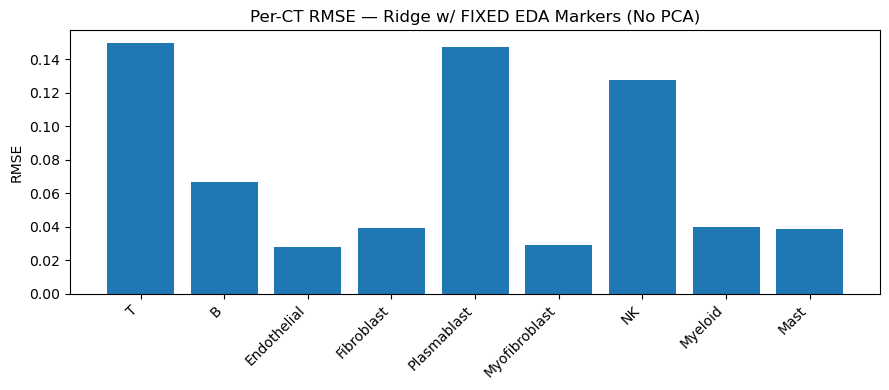


=== TEST PREDICTIONS (simplex, sum=1 per sample) ===
             T         B  Endothelial  Fibroblast  Plasmablast  Myofibroblast  \
s5_0  0.596023  0.062640     0.028614    0.086124     0.005140       0.056172   
s5_1  0.586214  0.095371     0.027944    0.086700     0.001593       0.054863   
s5_2  0.592582  0.075349     0.029259    0.061647     0.002346       0.055611   
s5_3  0.596991  0.073057     0.026614    0.090803     0.001727       0.053722   
s5_4  0.582496  0.115804     0.032637    0.080136     0.002068       0.053433   

            NK   Myeloid      Mast  
s5_0  0.112103  0.043964  0.009221  
s5_1  0.108365  0.030829  0.008121  
s5_2  0.087330  0.088818  0.007058  
s5_3  0.114119  0.033619  0.009349  
s5_4  0.064972  0.054837  0.013617  


In [14]:
# ===== Ridge(ILR) with FIXED markers from EDA (markers_union) =====
from __future__ import annotations
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, random, warnings
warnings.filterwarnings("ignore")

# --- assumes markers_union & markers_combined_by_ct are already defined in the notebook ---
assert 'markers_union_pruned' in globals() and isinstance(markers_union_pruned, (list, tuple)) and len(markers_union_pruned)>0, \
    "markers_union 不存在或為空。請先跑前一個 EDA cell 取得 markers_union。"

# ===== PATHS =====
AD_TRAIN_PATH   = r"../train_data/train_adata.h5ad"
AD_TEST_PATH    = r"../test_data/test_adata.h5ad"
BULK_TRAIN_PATH = r"../train_data/train_bulk.csv"         # genes × n_train
BULK_TEST_PATH  = r"../test_data/test_bulk.csv"           # genes × n_test
TRUE_PATH       = r"../train_data/train_bulk_trueprops.csv"

# ===== SETTINGS =====
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
INNER_N_FOLDS  = 5
RIDGE_ALPHA    = 1e-2
SEED           = 42

# ---- Joint bulk preprocess (train+test together; NO PCA) ----
GLOBAL_WINSORIZE = True
GLOBAL_WINSOR_Q  = 0.995
GLOBAL_ASINH     = True
GLOBAL_ASINH_C   = 1.0

np.random.seed(SEED); random.seed(SEED)

# ===== utils (same as before) =====
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.log1p(ad)  # 不影響這個 cell；这里只是佔位

def cpm10k(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0).astype(float); lib[lib==0.0] = 1.0
    return df.div(lib, axis=1) * 1e4

def winsorize_per_gene_pairwise(Btr: pd.DataFrame, Bte: pd.DataFrame, q: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    joint = pd.concat([Btr, Bte], axis=1)
    up = joint.quantile(q, axis=1)
    return Btr.clip(lower=0.0, upper=up, axis=0), Bte.clip(lower=0.0, upper=up, axis=0)

def asinh_vst(df: pd.DataFrame, c: float = 1.0) -> pd.DataFrame:
    return np.arcsinh(df / float(c))

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]; cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ===== load =====
sc = need_scanpy()
ad_tr = sc.read_h5ad(AD_TRAIN_PATH)
ad_te = sc.read_h5ad(AD_TEST_PATH)  # 不參與 marker；保留以備擴充
bulk_tr_raw = pd.read_csv(BULK_TRAIN_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te_raw = pd.read_csv(BULK_TEST_PATH,  index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth       = pd.read_csv(TRUE_PATH, index_col=0)

# genes 對齊
genes = bulk_tr_raw.index.intersection(bulk_te_raw.index).astype(str)
bulk_tr_raw = bulk_tr_raw.loc[genes].astype(float)
bulk_te_raw = bulk_te_raw.loc[genes].astype(float)

# ---- Joint bulk preprocess（CP10k + joint winsor + joint asinh；無 PCA）----
Btr = cpm10k(bulk_tr_raw.copy())
Bte = cpm10k(bulk_te_raw.copy())
if GLOBAL_WINSORIZE:
    Btr, Bte = winsorize_per_gene_pairwise(Btr, Bte, GLOBAL_WINSOR_Q)
if GLOBAL_ASINH:
    Btr = asinh_vst(Btr, GLOBAL_ASINH_C)
    Bte = asinh_vst(Bte, GLOBAL_ASINH_C)

B_all  = Btr   # genes × n_train
B_test = Bte   # genes × n_test

# train truth 對齊
for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0
T_all = truth.loc[TARGET_ORDER, B_all.columns].T  # (n_train × K)

# sample -> patient（train）
if CELLTYPE_COL not in ad_tr.obs:
    if "cell_type" in ad_tr.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in train adata.obs")
if "Sample" not in ad_tr.obs or "Patient" not in ad_tr.obs:
    raise KeyError("train adata.obs needs 'Sample' and 'Patient'")

sample_to_patient = ad_tr.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample_train  = {c: parse_sample_from_bulk_col(c) for c in B_all.columns}
col_to_patient_train = {c: sample_to_patient.get(col_to_sample_train[c], "UNK") for c in B_all.columns}

keep_cols = [c for c in B_all.columns if col_to_patient_train[c]!="UNK" and c in T_all.index]
B_all = B_all[keep_cols]
T_all = T_all.loc[keep_cols]
patients_all = sorted({col_to_patient_train[c] for c in keep_cols})

# ===== FIXED MARKERS from EDA =====
markers_union_pruned = list(dict.fromkeys(markers_union_pruned))  # 去重保序
genes_used_union = pd.Index(markers_union_pruned, dtype=str).intersection(B_all.index).intersection(B_test.index)
if len(genes_used_union) < 20:
    raise ValueError(f"可用 markers 交集太少：{len(genes_used_union)}（檢查 gene naming 與大小寫）")

# ILR basis
Kc = len(TARGET_ORDER); H = helmert_basis(Kc)

# ===== LOPO + inner K-fold（固定 markers；僅做模型 bagging）=====
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

preds_by_sample_train: dict[str, list[np.ndarray]] = {}
truth_by_sample_train: dict[str, np.ndarray] = {}
patient_of_col_train: dict[str, str] = {}
bag_y_test_allfolds: dict[str, list[np.ndarray]] = {c: [] for c in B_test.columns}

for p_test in patients_all:
    test_cols_train_outer = [c for c in B_all.columns if col_to_patient_train[c]==p_test]
    if not test_cols_train_outer: 
        continue

    others = [p for p in patients_all if p != p_test]
    if not others:
        continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    bag_y_train_outer: dict[str, list[np.ndarray]] = {c: [] for c in test_cols_train_outer}

    # --- 固定使用 genes_used_union ---
    tr_cols_all_others = [c for c in B_all.columns if col_to_patient_train[c] in others]
    if len(tr_cols_all_others) < 2:
        continue  # 沒有足夠訓練樣本

    for in_id, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())

        tr_cols_inner = [c for c in B_all.columns if col_to_patient_train[c] in in_tr_pats]
        if len(tr_cols_inner) < 2:
            continue

        X_tr_sg    = B_all.loc[genes_used_union, tr_cols_inner].T
        X_te_train = B_all.loc[genes_used_union, test_cols_train_outer].T
        X_te_real  = B_test.loc[genes_used_union, B_test.columns].T

        # Ridge on ILR
        y_in_tr = T_all.loc[tr_cols_inner].values
        z_in_tr = ilr(y_in_tr, H)
        model = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        model.fit(X_tr_sg, z_in_tr)

        # train outer-test
        z_pred_train = model.predict(X_te_train)
        y_pred_train = ilr_inv(z_pred_train, H)
        y_pred_train = np.vstack([simplex_proj(row) for row in y_pred_train])
        for i, col in enumerate(test_cols_train_outer):
            bag_y_train_outer[col].append(y_pred_train[i])

        # real test
        z_pred_real = model.predict(X_te_real)
        y_pred_real = ilr_inv(z_pred_real, H)
        y_pred_real = np.vstack([simplex_proj(row) for row in y_pred_real])
        for i, col in enumerate(B_test.columns):
            bag_y_test_allfolds[col].append(y_pred_real[i])

    # 此 outer 的 train 外測聚合
    for col in test_cols_train_outer:
        truth_by_sample_train[col] = T_all.loc[col].values
        patient_of_col_train[col]  = p_test
        if len(bag_y_train_outer[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y_train_outer[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample_train.setdefault(col, []).append(y_mean)

# ===== 訓練集評估（train outer-test）=====
cols_eval = sorted(truth_by_sample_train.keys())
Y_true = np.vstack([truth_by_sample_train[c] for c in cols_eval])
Y_pred_fixed = np.vstack([simplex_proj(np.vstack(preds_by_sample_train[c]).mean(axis=0)) for c in cols_eval])

rmse_ct = np.sqrt(((Y_pred_fixed - Y_true)**2).mean(axis=0))
avg_rmse = float(rmse_ct.mean()); per_ct = pd.Series(rmse_ct, index=TARGET_ORDER)

print("\n=== TRAIN EVAL — LOPO + inner K-fold | FIXED markers (from EDA) | NO PCA ===")
print(f"Markers used (union) = {len(genes_used_union)} genes")
print(f"Joint preprocess: CP10k + winsor({GLOBAL_WINSORIZE}, q={GLOBAL_WINSOR_Q}) + asinh({GLOBAL_ASINH}, c={GLOBAL_ASINH_C})")
print(f"INNER folds up to {INNER_N_FOLDS} | Ridge α={RIDGE_ALPHA}")
print(f"Total train samples evaluated = {len(cols_eval)}")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER, per_ct.values)
plt.xticks(rotation=45, ha="right"); plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge w/ FIXED EDA Markers (No PCA)")
plt.tight_layout(); plt.show()

# ===== 真 TEST 聚合（跨所有 outer×inner）=====
Y_test_final = []
for col in B_test.columns:
    if len(bag_y_test_allfolds[col]) > 0:
        y_mean = simplex_proj(np.mean(np.vstack(bag_y_test_allfolds[col]), axis=0))
    else:
        y_mean = np.ones(Kc)/Kc
    Y_test_final.append(y_mean)
Y_test_final = np.vstack(Y_test_final)

df_test_pred = pd.DataFrame(Y_test_final, index=B_test.columns, columns=TARGET_ORDER)
print("\n=== TEST PREDICTIONS (simplex, sum=1 per sample) ===")
print(df_test_pred.head())

# 可選：存檔
# df_test_pred.to_csv("../predictions/test_props_fixedMarkers_ridge.csv")


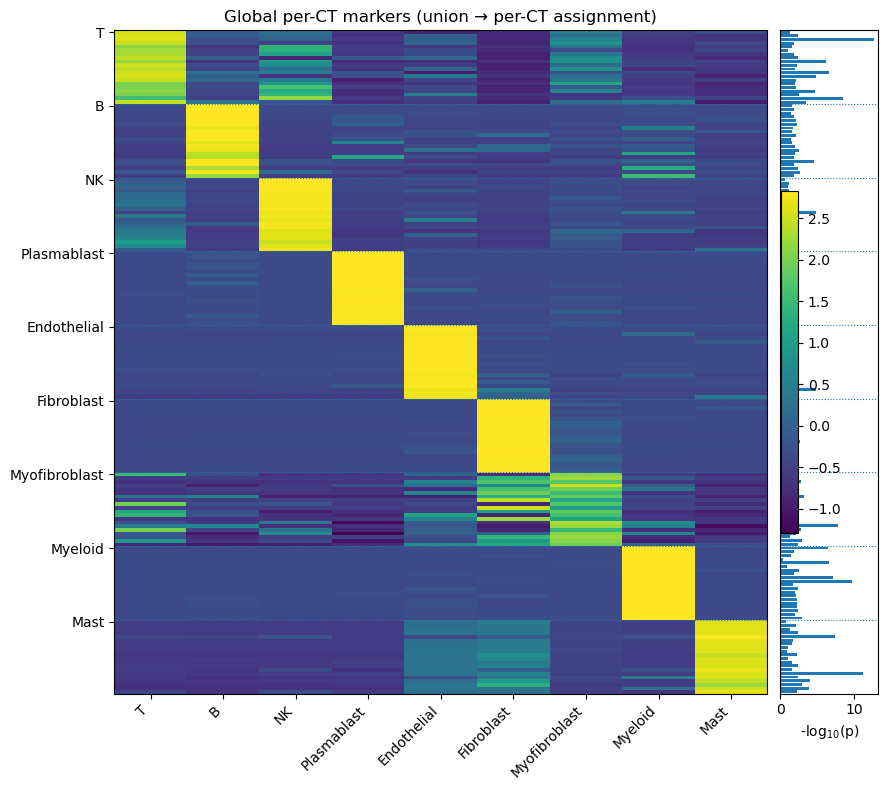

In [282]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from math import ceil
from scipy.stats import ttest_ind

# ========== 小工具：依 CT 聚合 sample|CT → 取平均（用來畫熱圖） ==========
def mean_by_ct(pb: pd.DataFrame) -> pd.DataFrame:
    # pb: genes × (sample|CT)
    tags = [c.split("|",1)[1] for c in pb.columns]
    out = {}
    for ct in sorted(set(tags)):
        cols = [c for c,t in zip(pb.columns, tags) if t==ct]
        if cols:
            out[ct] = pb[cols].mean(axis=1)
    return pd.DataFrame(out)  # genes × CT

# ========== p-value：該 CT vs 其它 CT（Welch t-test） ==========
def pvals_by_ct(pb: pd.DataFrame, ct_list: list[str]) -> pd.DataFrame:
    # 對每個基因、每個 CT：該 CT 所有 (sample|CT) 欄與其餘 CT 欄做 Welch t-test
    tags = [c.split("|",1)[1] for c in pb.columns]
    res = {}
    for ct in ct_list:
        in_cols  = [c for c,t in zip(pb.columns, tags) if t==ct]
        out_cols = [c for c,t in zip(pb.columns, tags) if t!=ct]
        if len(in_cols) < 2 or len(out_cols) < 2:
            # 样本太少，回 NaN
            res[ct] = pd.Series(np.nan, index=pb.index)
            continue
        # t-test per gene（Welch, equal_var=False）
        p = []
        for g in pb.index:
            a = pb.loc[g, in_cols].astype(float).values
            b = pb.loc[g, out_cols].astype(float).values
            _, pv = ttest_ind(a, b, equal_var=False, nan_policy="omit")
            p.append(pv)
        res[ct] = pd.Series(p, index=pb.index)
    return pd.DataFrame(res)  # genes × CT （p值）

# ========== 取得每個 CT 的 marker → dict(CT -> [genes])，並維持給定順序 ==========
def pack_markers_per_ct(cts: list[str], marker_list: list[str], pb_ct_mean: pd.DataFrame) -> dict[str, list[str]]:
    # 用「該 CT 的表現 / 其它平均」排名來決定該 CT 的前 k 個基因；這能把一個 union 的 gene set 分配回各 CT
    gene_set = [g for g in marker_list if g in pb_ct_mean.index]
    res = {ct: [] for ct in cts}
    if len(gene_set)==0:
        return res
    # score(g, ct) = log2( mean_ct / mean_rest )
    M = pb_ct_mean.loc[gene_set, cts]
    mean_all = M.mean(axis=1) + 1e-9
    for ct in cts:
        m_ct = M[ct] + 1e-9
        rest = (mean_all * len(cts) - m_ct) / max(1, (len(cts)-1))
        score = np.log2(m_ct / rest)
        # 把所有 gene 按對該 CT 的分數排序，挑前 ceil(len(marker_list)/len(cts))
        k = max(1, ceil(len(marker_list) / max(1, len(cts))))
        res[ct] = score.sort_values(ascending=False).index[:k].tolist()
    return res

# ========== 畫 heatmap：按 CT 區塊堆疊；T/B/NK 靠在一起 ==========
def plot_marker_heatmap(pb: pd.DataFrame,
                        markers_by_ct: dict[str, list[str]],
                        column_ct_order: list[str],
                        title: str,
                        show_pbars: bool = True,
                        pval_df: pd.DataFrame | None = None,
                        figsize=(9,8)):
    """
    pb: genes × (sample|CT)（建議用 ComBat 後的 pseudobulk）
    markers_by_ct: {ct: [gene1, gene2, ...]}
    column_ct_order: heatmap 的 CT 欄順序（會把 T, B, NK 擺在一起）
    pval_df: （可選）genes×CT 的 p 值表，用來畫 -log10 p 的右側條圖
    """
    # 每 CT 平均（畫圖比較穩）
    M = mean_by_ct(pb)  # genes × CT
    col_order = [ct for ct in column_ct_order if ct in M.columns]
    # 依 CT block 組合 rows
    row_labels = []
    for ct in column_ct_order:
        row_labels.extend([ (ct, g) for g in markers_by_ct.get(ct, []) if g in M.index ])
    if len(row_labels)==0:
        print(f"[{title}] 沒有可用的 marker 可畫。")
        return
    rows = [g for (_,g) in row_labels]
    mat = M.loc[rows, col_order].astype(float).values

    # 每個 gene 在 CT 維度 z-score（橫向標準化，讓對比清楚）
    mat = (mat - mat.mean(axis=1, keepdims=True)) / (mat.std(axis=1, keepdims=True) + 1e-9)

    # 為畫分隔線計算每個 block 的累積行索引
    block_sizes = [len([1 for (ct,_) in row_labels if ct==ct_name]) for ct_name in column_ct_order]
    block_pos = np.cumsum([0] + block_sizes)

    # 畫 heatmap
    plt.figure(figsize=figsize)
    im = plt.imshow(mat, aspect="auto")
    plt.xticks(range(len(col_order)), col_order, rotation=45, ha="right")
    # ytick 標示：只在每個 CT 區塊的第一行寫 CT 名（避免太擠）
    ytick_pos = []
    ytick_lab = []
    for i,ct in enumerate(column_ct_order):
        if block_sizes[i] > 0:
            ytick_pos.append(block_pos[i])
            ytick_lab.append(ct)
    plt.yticks(ytick_pos, ytick_lab)
    for y in block_pos:
        plt.axhline(y-0.5, linestyle=":", linewidth=0.8)
    plt.title(title)
    plt.colorbar(im, fraction=0.025, pad=0.02)

    # 可選：右側畫 -log10 p bar（針對各 CT 的該 CT vs 其餘）
    if show_pbars and (pval_df is not None):
        # 只抓對應到 row 的 (ct,gene) p 值
        ax = plt.gca()
        ax2 = ax.inset_axes([1.02, 0.0, 0.15, 1.0])  # 右側內嵌座標
        bars = []
        for (ct,g) in row_labels:
            pv = pval_df.loc[g, ct] if (g in pval_df.index and ct in pval_df.columns) else np.nan
            bars.append(-np.log10(pv) if (pv is not None and np.isfinite(pv) and pv>0) else 0.0)
        # 畫水平條
        y = np.arange(len(bars))
        ax2.barh(y, bars)
        ax2.set_ylim(-0.5, len(bars)-0.5)
        ax2.set_yticks([])  # 不重複 ytick
        ax2.set_xlabel(r"-log$_{10}$(p)")
        # 同步 block 分隔線
        for yy in block_pos:
            ax2.axhline(yy-0.5, linestyle=":", linewidth=0.8)

    plt.tight_layout()
    plt.show()

# ========== 方便函式：從「一個 gene list」還原為 per-CT 分配後畫圖 ==========
def plot_from_union_markerlist(pb: pd.DataFrame,
                               marker_union: list[str],
                               ct_order: list[str],
                               title: str,
                               pval_out_csv: str | None = None):
    M_ct = mean_by_ct(pb)
    # 把 union 的基因分配回每個 CT（用 log-ratio 排序）
    markers_by_ct = pack_markers_per_ct(ct_order, marker_union, M_ct)
    # p-value 計算並存檔
    pvals = pvals_by_ct(pb, ct_order)
    if pval_out_csv:
        pvals.loc[sorted(set(marker_union).intersection(pvals.index))].to_csv(pval_out_csv)
    plot_marker_heatmap(pb, markers_by_ct, ct_order, title, show_pbars=True, pval_df=pvals)

# 指定你喜歡的欄順序（T/B/NK 靠一起）
nice_ct_order = ["T","B","NK","Plasmablast","Endothelial","Fibroblast","Myofibroblast","Myeloid","Mast"]
nice_ct_order = [ct for ct in nice_ct_order if ct in {c.split("|",1)[1] for c in pb_all.columns}]

# 1) Global per-CT union markers（你原本的 stratified_marker_union）
markers_global = stratified_marker_union(pb_all, topk_per_ct=20, ct_order=nice_ct_order)
plot_from_union_markerlist(pb_all,
                           markers_global,
                           nice_ct_order,
                           title="Global per-CT markers (union → per-CT assignment)",
                           pval_out_csv="markers_global_pvals.csv")

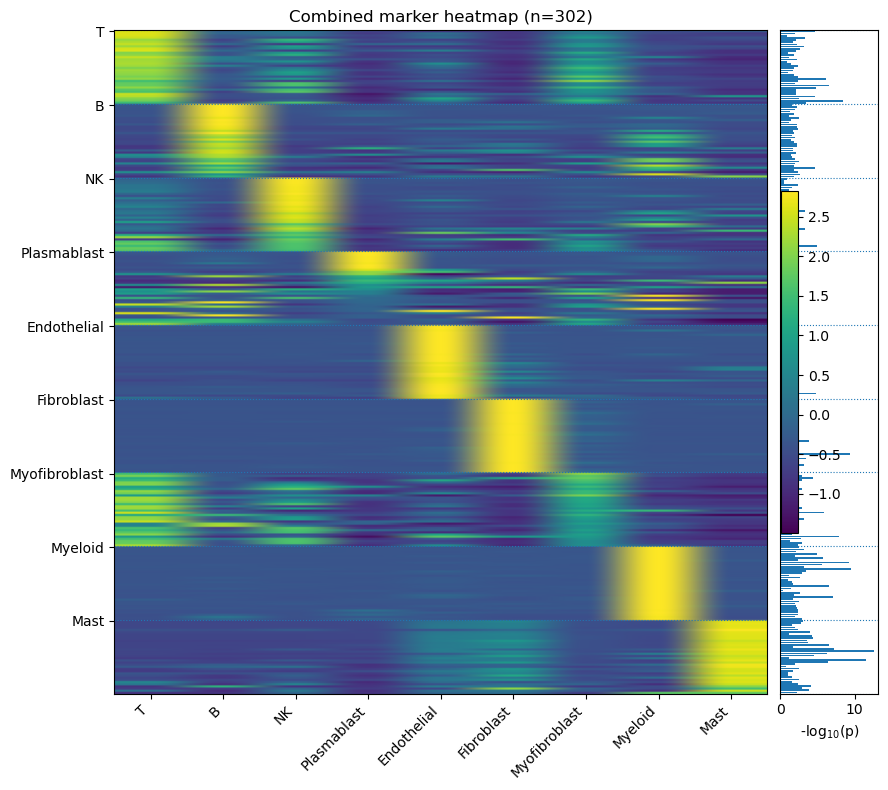

Total combined markers used: 302


In [281]:
# ------- Combine lymph + non markers, filter, then plot one big heatmap -------
mark_lymph = markers_within_lymph(pb_all, topk_per_ct=max(20, MARKER_TOPK_CT//3))
mark_non = markers_within_non(pb_all, topk_per_ct=max(20, MARKER_TOPK_CT//3))
# 想讓 T/B/NK/Plasmablast 靠一起的欄順序
nice_ct_order = ["T","B","NK","Plasmablast",
                 "Endothelial","Fibroblast","Myofibroblast","Myeloid","Mast"]

# 1) 合併 & 去重；只保留出現在 pb_all 的基因
genes_in_pb = set(pb_all.index.astype(str))
marker_union = list( (set(mark_lymph) | set(mark_non)) & genes_in_pb )

# （可選）2) 過濾免疫球蛋白與 TCR 可變區（避免個體化超變異蓋掉 cell-type 訊號）
FILTER_IG_TCR = True
if FILTER_IG_TCR:
    bad_prefix = ("IGH","IGK","IGL","TRB","TRA","TRG","TRD")
    marker_union = [g for g in marker_union if not str(g).upper().startswith(bad_prefix)]

# （可選）3) 限制總基因數（讓圖不要太擠）——依每個 CT 的對比分數自動均分挑前 N
# 設成 None 就不限制；例如想大概 500 個：
TOTAL_CAP = None  # 例如 500
if TOTAL_CAP is not None and len(marker_union) > TOTAL_CAP:
    # 用 pack_markers_per_ct 幫忙按 CT 均分挑前 N
    M_ct = mean_by_ct(pb_all)
    per_ct = max(1, int(TOTAL_CAP / max(1, len(nice_ct_order))))
    # 先分配（這步會按各 CT 的 log-ratio 排序）
    prelim = pack_markers_per_ct(nice_ct_order, marker_union, M_ct)
    # 每個 CT 取前 per_ct，最後再合併（並保持順序）
    marker_union = []
    for ct in nice_ct_order:
        picked = prelim.get(ct, [])[:per_ct]
        marker_union.extend(picked)
    # 去重保持先來後到
    seen = set(); marker_union = [g for g in marker_union if not (g in seen or seen.add(g))]


# 4) 畫圖 &（可選）輸出 p 值表
plot_from_union_markerlist(
    pb=pb_all,
    marker_union=marker_union,
    ct_order=nice_ct_order,
    title=f"Combined marker heatmap (n={len(marker_union)})",
    pval_out_csv=None  # 例如 "../figs/combined_markers_pvals.csv"
)

# 小檢查：印 union 量與每個 CT 大約分配多少
print(f"Total combined markers used: {len(marker_union)}")


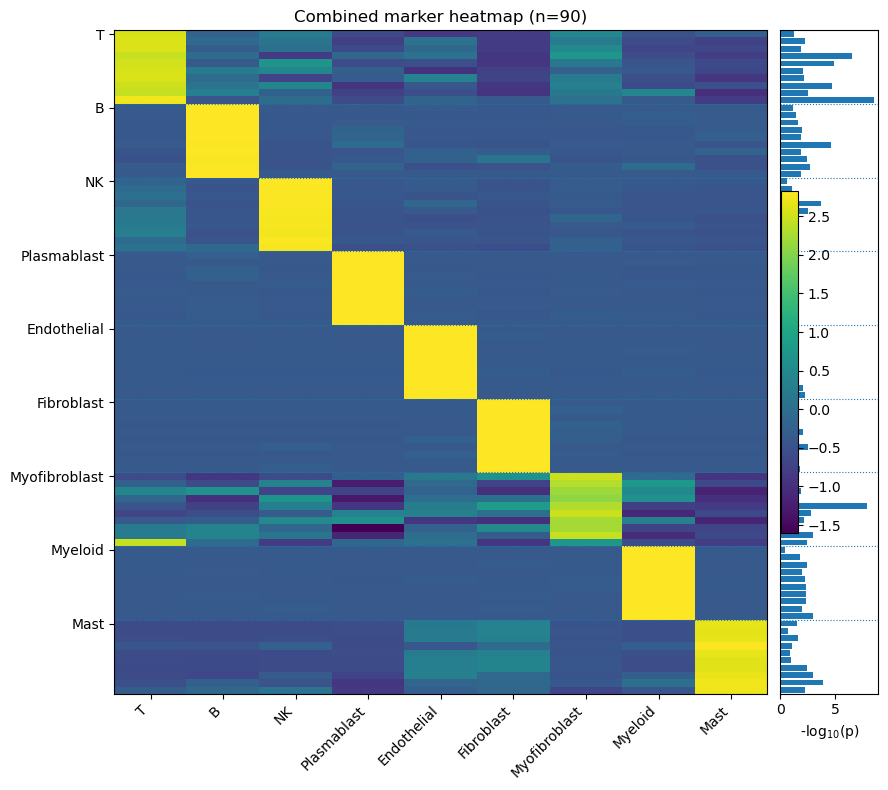

In [280]:
markers = mean_ratio_markers(pb_all, topk_per_ct=10, ct_order=TARGET_ORDER, pseudocount=1e-9, min_cols_per_ct=1)
# 4) 畫圖 &（可選）輸出 p 值表
plot_from_union_markerlist(
    pb=pb_all,
    marker_union=markers,
    ct_order=nice_ct_order,
    title=f"Combined marker heatmap (n={len(markers)})",
    pval_out_csv=None  # 例如 "../figs/combined_markers_pvals.csv"
)

In [258]:
import numpy as np, pandas as pd
from math import ceil
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def _columns_by_ct(pb: pd.DataFrame, cts: list[str]) -> dict[str, list[str]]:
    tags = [c.split("|",1)[1] for c in pb.columns]
    col_map = {ct: [col for col, t in zip(pb.columns, tags) if t==ct] for ct in cts}
    return col_map

def _one_vs_rest_stats(pb_sub: pd.DataFrame, in_cols: list[str], out_cols: list[str]) -> pd.DataFrame:
    # per-gene Welch t-test（equal_var=False） + log2FC
    A = pb_sub[in_cols].astype(float)
    B = pb_sub[out_cols].astype(float)
    muA = A.mean(axis=1); muB = B.mean(axis=1)
    # 避免 0
    eps = 1e-9
    l2fc = np.log2((muA + eps) / (muB + eps))
    pvals = []
    for g in pb_sub.index:
        a = A.loc[g].values; b = B.loc[g].values
        _, pv = ttest_ind(a, b, equal_var=False, nan_policy="omit")
        pvals.append(pv)
    out = pd.DataFrame({"log2FC": l2fc, "p": pvals}, index=pb_sub.index)
    return out

def _corr_prune(pb_sub: pd.DataFrame, genes_sorted: list[str], corr_thr: float, min_k: int, max_k: int) -> list[str]:
    # 用子空間所有樣本的表達（columns=子空間所有 sample|CT）計算相關，逐步剔除高相關
    X = pb_sub.loc[genes_sorted].astype(float).values
    sel = []
    for i, g in enumerate(genes_sorted):
        if len(sel) == 0:
            sel.append(i); 
            if len(sel) >= max_k: break
            continue
        # 與目前已選的最大 |corr|
        v = X[i]
        Xsel = X[sel]
        # 手算相關，避免大矩陣
        v_ = (v - v.mean()) / (v.std() + 1e-9)
        Xs_ = (Xsel - Xsel.mean(axis=1, keepdims=True)) / (Xsel.std(axis=1, keepdims=True) + 1e-9)
        corrs = (Xs_ @ v_) / (v_.shape[0] - 1)
        if np.max(np.abs(corrs)) < corr_thr:
            sel.append(i)
            if len(sel) >= max_k: break
    # 若還不到 min_k，就放寬相關閾值再補
    if len(sel) < min_k:
        need = min_k - len(sel)
        for j in range(len(genes_sorted)):
            if j in sel: continue
            sel.append(j)
            if len(sel) >= min_k: break
    return [genes_sorted[i] for i in sel]

def select_markers_adaptive(pb: pd.DataFrame,
                            ct_list: list[str],
                            alpha_q: float = 0.01,
                            lfc_min: float = 0.5,
                            expr_min: float = 0.0,
                            min_samps_per_side: int = 2,
                            corr_thr: float = 0.9,
                            min_k: int = 10,
                            max_k: int = 150) -> dict[str, list[str]]:
    """
    pb: genes × (sample|CT) 的 pseudobulk（建議先 ComBat）
    回傳：{ct: [markers...]}，每個 CT 自動決定數量（落在 [min_k, max_k] 之間）
    """
    cols_map = _columns_by_ct(pb, ct_list)
    # 子空間的所有欄（只在 subspace 內評估 separability）
    sub_cols = sum([cols_map[ct] for ct in ct_list], [])
    pb_sub = pb.loc[:, sub_cols].copy()
    res = {ct: [] for ct in ct_list}

    for ct in ct_list:
        in_cols  = cols_map[ct]
        out_cols = [c for c in sub_cols if c not in in_cols]
        if len(in_cols) < min_samps_per_side or len(out_cols) < min_samps_per_side:
            continue

        stats = _one_vs_rest_stats(pb_sub, in_cols, out_cols)
        # 表達濾除：均值太低容易雜訊
        mu_ct  = pb_sub[in_cols].mean(axis=1)
        mu_out = pb_sub[out_cols].mean(axis=1)
        stats["mu_ct"] = mu_ct; stats["mu_out"] = mu_out

        # FDR（BH）
        q = multipletests(stats["p"].values, alpha=alpha_q, method="fdr_bh")[1]
        stats["q"] = q

        # 只留「顯著上調」且「效果量足夠」且「有一定表達」的基因
        keep = stats[(stats["q"] <= alpha_q) &
                     (stats["log2FC"] >= lfc_min) &
                     (stats["mu_ct"] >= expr_min)]
        if keep.empty:
            # 若太嚴苛，退而取 top by score
            tmp = stats.copy()
            tmp["score"] = tmp["log2FC"] * (-np.log10(tmp["p"] + 1e-300))
            genes_sorted = tmp.sort_values("score", ascending=False).index.tolist()
        else:
            keep["score"] = keep["log2FC"] * (-np.log10(keep["q"] + 1e-300))
            genes_sorted = keep.sort_values("score", ascending=False).index.tolist()

        # 冗餘剔除（相關）
        genes_pruned = _corr_prune(pb_sub, genes_sorted, corr_thr=corr_thr, min_k=min_k, max_k=max_k)
        res[ct] = genes_pruned
    return res

# 兩個便捷包裝：淋巴 / 非淋巴
def markers_within_lymph_adaptive(pb: pd.DataFrame,
                                  alpha_q=0.01, lfc_min=0.5, expr_min=0.0,
                                  corr_thr=0.9, min_k=10, max_k=150):
    lymph_cts = [ct for ct in ["T","B","NK","Plasmablast"] if any(c.split("|",1)[1]==ct for c in pb.columns)]
    return select_markers_adaptive(pb, lymph_cts, alpha_q, lfc_min, expr_min,
                                   min_samps_per_side=2, corr_thr=corr_thr, min_k=min_k, max_k=max_k)

def markers_within_non_adaptive(pb: pd.DataFrame,
                                alpha_q=0.01, lfc_min=0.5, expr_min=0.0,
                                corr_thr=0.9, min_k=10, max_k=150):
    non_cts = [ct for ct in ["Endothelial","Fibroblast","Myofibroblast","Myeloid","Mast"]
               if any(c.split("|",1)[1]==ct for c in pb.columns)]
    return select_markers_adaptive(pb, non_cts, alpha_q, lfc_min, expr_min,
                                   min_samps_per_side=2, corr_thr=corr_thr, min_k=min_k, max_k=max_k)


In [259]:
# 自適應挑 marker（數量自決）
markers_lymph_dict = markers_within_lymph_adaptive(
    pb_all,
    alpha_q=0.01,     # FDR 門檻（可調 0.05/0.1 看資料量）
    lfc_min=0.5,      # log2FC 最小效果量（0.5 ≈ 1.41 倍）
    expr_min=0.0,     # 可設為 0.1~1 之類，過低表達排除
    corr_thr=0.9,     # 冗餘剔除相關閾值（越小越嚴格）
    min_k=10,         # 每 CT 至少取幾個（避免太少）
    max_k=150         # 每 CT 最多取幾個（避免太多）
)
markers_non_dict = markers_within_non_adaptive(
    pb_all, alpha_q=0.01, lfc_min=0.5, expr_min=0.0, corr_thr=0.9, min_k=10, max_k=150
)

# 你要的是「union」還是「分開用」：
# 若只要做一階段模型，可把兩邊 union 起來：
markers_union = sorted(set(sum(markers_lymph_dict.values(), [])) | set(sum(markers_non_dict.values(), [])))

# 下一步跟你原本一樣：跟 B_all/B_test 的基因交集後丟進模型
genes_used = pd.Index(markers_union, dtype=str).intersection(B_all.index).intersection(B_test.index)


In [261]:
import numpy as np, pandas as pd
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

def _columns_by_ct(pb: pd.DataFrame, cts: list[str]) -> dict[str, list[str]]:
    tags = [c.split("|",1)[1] for c in pb.columns]
    return {ct: [col for col, t in zip(pb.columns, tags) if t==ct] for ct in cts}

def _one_vs_rest_stats(pb_sub: pd.DataFrame, in_cols: list[str], out_cols: list[str]) -> pd.DataFrame:
    A = pb_sub[in_cols].astype(float)
    B = pb_sub[out_cols].astype(float)
    muA = A.mean(axis=1); muB = B.mean(axis=1)
    eps = 1e-9
    l2fc = np.log2((muA + eps) / (muB + eps))
    pvals = []
    for g in pb_sub.index:
        a = A.loc[g].values; b = B.loc[g].values
        _, pv = ttest_ind(a, b, equal_var=False, nan_policy="omit")
        pvals.append(pv)
    out = pd.DataFrame({"log2FC": l2fc, "p": pvals}, index=pb_sub.index)
    return out

def _corr_prune(pb_sub: pd.DataFrame, genes_sorted: list[str], corr_thr: float, min_k: int, max_k: int) -> list[str]:
    if len(genes_sorted) == 0:
        return []
    X = pb_sub.loc[genes_sorted].astype(float).values
    sel = []
    for i in range(len(genes_sorted)):
        if len(sel) == 0:
            sel.append(i)
            if len(sel) >= max_k: break
            continue
        v = X[i]
        Xsel = X[sel]
        v_ = (v - v.mean()) / (v.std() + 1e-9)
        Xs_ = (Xsel - Xsel.mean(axis=1, keepdims=True)) / (Xsel.std(axis=1, keepdims=True) + 1e-9)
        corrs = (Xs_ @ v_) / (v_.shape[0] - 1)
        if np.max(np.abs(corrs)) < corr_thr:
            sel.append(i)
            if len(sel) >= max_k: break
    if len(sel) < min_k:
        for j in range(len(genes_sorted)):
            if j in sel: continue
            sel.append(j)
            if len(sel) >= min_k: break
    return [genes_sorted[i] for i in sel]

def select_markers_adaptive_with_stats(
    pb: pd.DataFrame, ct_list: list[str],
    alpha_q=0.01, lfc_min=0.5, expr_min=0.0,
    min_samps_per_side=2, corr_thr=0.9, min_k=10, max_k=150
) -> tuple[dict[str, list[str]], pd.DataFrame]:
    """
    回傳:
      markers_dict: {ct: [genes...]}（每個 CT 自動決定數量）
      stats_long:   每個子空間內一對多檢定的表，含 log2FC / p / q / score / ct
    """
    cols_map = _columns_by_ct(pb, ct_list)
    sub_cols = sum([cols_map[ct] for ct in ct_list], [])
    pb_sub = pb.loc[:, sub_cols].copy()

    all_rows = []
    markers = {}

    for ct in ct_list:
        in_cols  = cols_map[ct]
        out_cols = [c for c in sub_cols if c not in in_cols]
        if len(in_cols) < min_samps_per_side or len(out_cols) < min_samps_per_side:
            markers[ct] = []
            continue

        stats = _one_vs_rest_stats(pb_sub, in_cols, out_cols)
        mu_ct  = pb_sub[in_cols].mean(axis=1)
        stats["mu_ct"] = mu_ct

        q = multipletests(stats["p"].values, alpha=alpha_q, method="fdr_bh")[1]
        stats["q"] = q
        stats["score"] = stats["log2FC"] * (-np.log10(stats["q"] + 1e-300))
        stats["ct"] = ct
        all_rows.append(stats)

        keep = stats[(stats["q"] <= alpha_q) &
                     (stats["log2FC"] >= lfc_min) &
                     (stats["mu_ct"] >= expr_min)]
        if keep.empty:
            genes_sorted = stats.sort_values("score", ascending=False).index.tolist()
        else:
            genes_sorted = keep.sort_values("score", ascending=False).index.tolist()

        genes_pruned = _corr_prune(pb_sub, genes_sorted, corr_thr=corr_thr, min_k=min_k, max_k=max_k)
        markers[ct] = genes_pruned

    stats_long = pd.concat(all_rows, axis=0) if len(all_rows) else pd.DataFrame()
    return markers, stats_long

def markers_within_lymph_adaptive_with_stats(pb, **kw):
    lymph_cts = [ct for ct in ["T","B","NK","Plasmablast"]
                 if any(c.split("|",1)[1]==ct for c in pb.columns)]
    return select_markers_adaptive_with_stats(pb, lymph_cts, **kw)

def markers_within_non_adaptive_with_stats(pb, **kw):
    non_cts = [ct for ct in ["Endothelial","Fibroblast","Myofibroblast","Myeloid","Mast"]
               if any(c.split("|",1)[1]==ct for c in pb.columns)]
    return select_markers_adaptive_with_stats(pb, non_cts, **kw)


In [262]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def _mean_by_ct(pb: pd.DataFrame, ct_order: list[str]) -> tuple[pd.DataFrame, list[str], list[int]]:
    # 把同一個 CT 的所有 sample 併在一起（column concat），並且照 ct_order 排
    cols = []
    ct_ticks = []
    ct_edges = [0]
    for ct in ct_order:
        ct_cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not ct_cols: 
            continue
        cols.extend(ct_cols)
        ct_ticks.append(ct)
        ct_edges.append(len(cols))
    return pb.loc[:, cols], ct_ticks, ct_edges

def _zscore_rows(M: pd.DataFrame) -> pd.DataFrame:
    X = M.astype(float).values
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-9
    Z = (X - mu) / sd
    return pd.DataFrame(Z, index=M.index, columns=M.columns)

def plot_marker_heatmap(pb: pd.DataFrame, markers_dict: dict, ct_order: list[str], title: str):
    # 把每個 CT markers 串成一個 gene list（依 ct_order 併接，讓每個 CT 的基因黏在一起更好看）
    genes_concat = []
    row_ct_labels = []
    for ct in ct_order:
        gs = [g for g in markers_dict.get(ct, []) if g in pb.index]
        if len(gs)==0: 
            continue
        genes_concat.extend(gs)
        row_ct_labels.extend([ct]*len(gs))
    genes_concat = list(dict.fromkeys(genes_concat))  # 保留順序去重

    if len(genes_concat) == 0:
        print(f"[{title}] 沒有可畫的基因（這個子空間所有 CT 都沒選到 marker）。")
        return

    # 取子矩陣 & z-score（基因列標準化）
    pb_sorted, ct_ticks, ct_edges = _mean_by_ct(pb, ct_order)
    M = pb_sorted.loc[genes_concat]
    Z = _zscore_rows(M)

    # 畫圖（不要指定顏色，以預設 colormap）
    plt.figure(figsize=(12, min(18, 0.16*len(genes_concat) + 3)))
    plt.imshow(Z.values, aspect="auto", interpolation="nearest")
    plt.title(title)
    plt.xlabel("Samples grouped by CT")
    plt.ylabel("Markers (grouped by CT)")

    # x 軸：畫出 CT 區塊分隔線與刻度
    for x in ct_edges:
        plt.axvline(x-0.5, linewidth=1)
    midticks = [(ct_edges[i]+ct_edges[i+1]-1)/2 for i in range(len(ct_edges)-1)]
    plt.xticks(midticks, [ct for ct in ct_order if any(c.split("|",1)[1]==ct for c in pb.columns)], rotation=45, ha="right")

    # y 軸：每個 CT 的 marker 區塊也畫線
    # 找每個 ct 佔幾行
    y_edges = []
    idx = 0
    for ct in ct_order:
        k = sum(1 for lab in row_ct_labels if lab==ct)
        if k>0:
            y_edges.append(idx)
            idx += k
    y_edges.append(idx)
    for y in y_edges:
        plt.axhline(y-0.5, linewidth=1)

    plt.tight_layout()
    plt.show()


Found 3 genes with zero variance.
Found 2 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 2 genes with zero variance.
Found 4 genes with zero variance.
Found 3 genes with zero variance.
Found 2 genes with zero variance.

=== TRAIN EVAL — GROUPED (T+B+NK → Lymph_TBNK) ===
Avg RMSE = 0.0329
Per-CT RMSE:
Lymph_TBNK       0.0500
Plasmablast      0.0213
Endothelial      0.0261
Fibroblast       0.0278
Myofibroblast    0.0317
Myeloid          0.0378
Mast             0.0358


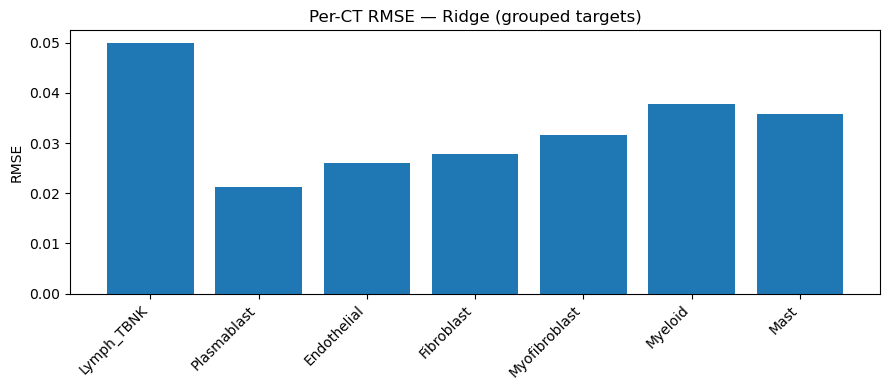


=== TEST PREDICTIONS (grouped targets) ===
      Lymph_TBNK  Plasmablast  Endothelial  Fibroblast  Myofibroblast  \
s5_0    0.735038     0.046180     0.025684    0.064937       0.086291   
s5_1    0.796725     0.006463     0.025463    0.080825       0.063203   
s5_2    0.761408     0.015360     0.026514    0.051491       0.084731   
s5_3    0.780844     0.015589     0.026269    0.075510       0.068232   
s5_4    0.768736     0.010561     0.028316    0.066524       0.079659   

       Myeloid      Mast  
s5_0  0.033122  0.008747  
s5_1  0.019275  0.008047  
s5_2  0.052438  0.008058  
s5_3  0.022353  0.011203  
s5_4  0.037105  0.009100  


In [21]:
# Jupyter cell: Joint-preproc bulk (train+test, no PCA) + LOPO(inner K) Ridge(ILR)
# Strategy: ilr_inv-per-fold → mean in simplex
from __future__ import annotations
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt, random, warnings
warnings.filterwarnings("ignore")

# ===== PATHS =====
AD_TRAIN_PATH   = r"../train_data/train_adata.h5ad"
AD_TEST_PATH    = r"../test_data/test_adata.h5ad"         # 不參與 marker（僅保留以備擴充）
BULK_TRAIN_PATH = r"../train_data/train_bulk.csv"         # genes × n_train
BULK_TEST_PATH  = r"../test_data/test_bulk.csv"           # genes × n_test
TRUE_PATH       = r"../train_data/train_bulk_trueprops.csv"

# ===== SETTINGS =====
CELLTYPE_COL   = "highLevelType"
TARGET_ORDER   = ["T","B","Endothelial","Fibroblast","Plasmablast","Myofibroblast","NK","Myeloid","Mast"]
MARKER_TOPK_CT = 25
INNER_N_FOLDS  = 5
RIDGE_ALPHA    = 1e-2
SEED           = 42

# ---- Joint bulk preprocess (train+test together; NO PCA) ----
GLOBAL_WINSORIZE = True
GLOBAL_WINSOR_Q  = 0.995
GLOBAL_ASINH     = True
GLOBAL_ASINH_C   = 1.0

np.random.seed(SEED); random.seed(SEED)

# ===== utils =====
def need_scanpy():
    import scanpy as sc
    return sc

def preprocess_sc(ad):
    sc = need_scanpy()
    sc.pp.log1p(ad)

def pseudobulk_by_sample_ct(ad, ct_col: str, sample_col: str) -> pd.DataFrame:
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = ad.X[idx]
        cols.append(np.asarray(Xi.mean(axis=0)).ravel()); names.append(f"{s}|{ct}")
    return pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

def combat_on_pb(pb: pd.DataFrame) -> pd.DataFrame:
    sc = need_scanpy()
    ad = sc.AnnData(pb.T.copy())
    ad.obs["batch"] = pd.Categorical([c.split("|",1)[0] for c in pb.columns])  # batch = Sample
    sc.pp.combat(ad, key="batch")
    return pd.DataFrame(ad.X.T, index=pb.index, columns=pb.columns)

def stratified_marker_union(pb: pd.DataFrame, topk_per_ct: int, ct_order: list[str]) -> list[str]:
    cts = sorted({c.split("|",1)[1] for c in pb.columns})
    order = [ct for ct in ct_order if ct in cts] + [ct for ct in cts if ct not in ct_order]
    mean_all = pb.mean(axis=1) + 1e-9
    sel = set()
    for ct in order:
        cols = [c for c in pb.columns if c.split("|",1)[1]==ct]
        if not cols: continue
        m_ct = pb[cols].mean(axis=1)
        rest = (mean_all * len(cts) - m_ct) / max(1e-12, (len(cts)-1))
        score = np.log2((m_ct+1e-9)/(rest+1e-9)).sort_values(ascending=False)
        sel.update(score.index[:topk_per_ct])
    return list(sel)

def cpm10k(df: pd.DataFrame) -> pd.DataFrame:
    lib = df.sum(axis=0).astype(float); lib[lib==0.0] = 1.0
    return df.div(lib, axis=1) * 1e4

def winsorize_per_gene_pairwise(Btr: pd.DataFrame, Bte: pd.DataFrame, q: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    joint = pd.concat([Btr, Bte], axis=1)
    up = joint.quantile(q, axis=1)
    return Btr.clip(lower=0.0, upper=up, axis=0), Bte.clip(lower=0.0, upper=up, axis=0)

def asinh_vst(df: pd.DataFrame, c: float = 1.0) -> pd.DataFrame:
    return np.arcsinh(df / float(c))

def parse_sample_from_bulk_col(col: str) -> str:
    m = re.match(r"^(s\d+)", str(col).lower())
    return m.group(1) if m else str(col)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]; cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# ILR
def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

# ===== load =====
sc = need_scanpy()
ad_tr = need_scanpy().read_h5ad(AD_TRAIN_PATH)
ad_te = need_scanpy().read_h5ad(AD_TEST_PATH)  # 不參與 marker；保留以備擴充
bulk_tr_raw = pd.read_csv(BULK_TRAIN_PATH, index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
bulk_te_raw = pd.read_csv(BULK_TEST_PATH,  index_col=0).apply(pd.to_numeric, errors="coerce").fillna(0.0)
truth       = pd.read_csv(TRUE_PATH, index_col=0)

# genes 對齊
genes = bulk_tr_raw.index.intersection(bulk_te_raw.index).astype(str)
bulk_tr_raw = bulk_tr_raw.loc[genes].astype(float)
bulk_te_raw = bulk_te_raw.loc[genes].astype(float)

# train sc preprocess（只用它選 marker）
preprocess_sc(ad_tr)

# ---- Joint bulk preprocess（CP10k + joint winsor + joint asinh；無 PCA）----
Btr = cpm10k(bulk_tr_raw.copy())
Bte = cpm10k(bulk_te_raw.copy())
if GLOBAL_WINSORIZE:
    Btr, Bte = winsorize_per_gene_pairwise(Btr, Bte, GLOBAL_WINSOR_Q)
if GLOBAL_ASINH:
    Btr = asinh_vst(Btr, GLOBAL_ASINH_C)
    Bte = asinh_vst(Bte, GLOBAL_ASINH_C)

B_all  = Btr   # genes × n_train
B_test = Bte   # genes × n_test

# train truth 對齊
for ct in TARGET_ORDER:
    if ct not in truth.index: truth.loc[ct] = 0.0
T_all = truth.loc[TARGET_ORDER, B_all.columns].T  # (n_train × K)

# sample -> patient（train）
if CELLTYPE_COL not in ad_tr.obs:
    if "cell_type" in ad_tr.obs: CELLTYPE_COL = "cell_type"
    else: raise KeyError("missing cell-type column in train adata.obs")
if "Sample" not in ad_tr.obs or "Patient" not in ad_tr.obs:
    raise KeyError("train adata.obs needs 'Sample' and 'Patient'")

sample_to_patient = ad_tr.obs[["Sample","Patient"]].drop_duplicates().set_index("Sample")["Patient"].astype(str)
col_to_sample_train  = {c: parse_sample_from_bulk_col(c) for c in B_all.columns}
col_to_patient_train = {c: sample_to_patient.get(col_to_sample_train[c], "UNK") for c in B_all.columns}

keep_cols = [c for c in B_all.columns if col_to_patient_train[c]!="UNK" and c in T_all.index]
B_all = B_all[keep_cols]
T_all = T_all.loc[keep_cols]
patients_all = sorted({col_to_patient_train[c] for c in keep_cols})

# ILR basis
# ===== 在讀完 truth 並建立 T_all 之後（你原本的位置：# train truth 對齊）加上這段 =====

# --- 新：定義群組，把 T/B/NK 合併成一類 ---
GROUPS_STAGE1 = {
    "Lymph_TBNK": ["T", "B", "NK"],  # 合併類
    # 其餘維持單獨輸出（順序可調）
    "Plasmablast": ["Plasmablast"],
    "Endothelial": ["Endothelial"],
    "Fibroblast": ["Fibroblast"],
    "Myofibroblast": ["Myofibroblast"],
    "Myeloid": ["Myeloid"],
    "Mast": ["Mast"],
}
TARGET_ORDER_G1 = ["Lymph_TBNK","Plasmablast","Endothelial","Fibroblast","Myofibroblast","Myeloid","Mast"]

def collapse_truth_to_groups(T_df: pd.DataFrame,
                             groups: dict[str, list[str]],
                             order: list[str]) -> pd.DataFrame:
    """
    T_df: (n_samples × K_orig) 的真值表（欄名是原始 CT，如 T/B/NK/...）
    groups: {"NewName": [old_ct1, old_ct2, ...]}
    order: 新 target 欄順序
    回傳: (n_samples × K_new)；每列總和依舊為 1（原本就為 1，且只是把幾欄相加）
    """
    out = {}
    for new_name, olds in groups.items():
        olds_in = [c for c in olds if c in T_df.columns]
        if len(olds_in) == 0:
            out[new_name] = pd.Series(0.0, index=T_df.index)
        else:
            out[new_name] = T_df[olds_in].sum(axis=1)
    df = pd.DataFrame(out).reindex(columns=order)
    # 保險起見做一次歸一化（理論上不需，但避免數值誤差）
    s = df.sum(axis=1).replace(0, 1.0)
    df = df.div(s, axis=0)
    return df

# 把原本的 T_all（n_train × K_orig）折疊成 T_all_g1（n_train × K_new）
T_all_g1 = collapse_truth_to_groups(T_all, GROUPS_STAGE1, TARGET_ORDER_G1)

# ---- 重新定義 ILR 基底（K 變成 K_new）----
Kc = len(TARGET_ORDER_G1)                 # <<< 替換原本的 Kc
H  = helmert_basis(Kc)                    # <<< 替換原本的 H

# ===== LOPO + inner K-fold（ilr_inv per fold → mean in simplex）=====
from sklearn.model_selection import KFold
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import Ridge

# containers（train eval）
preds_by_sample_train: dict[str, list[np.ndarray]] = {}
truth_by_sample_train: dict[str, np.ndarray] = {}
patient_of_col_train: dict[str, str] = {}

# containers（real test）
bag_y_test_allfolds: dict[str, list[np.ndarray]] = {c: [] for c in B_test.columns}

for p_test in patients_all:
    test_cols_train_outer = [c for c in B_all.columns if col_to_patient_train[c]==p_test]
    if not test_cols_train_outer: continue

    others = [p for p in patients_all if p != p_test]
    if not others: continue

    K_inner = min(INNER_N_FOLDS, max(1, len(others)))
    kf = KFold(n_splits=K_inner, shuffle=True, random_state=SEED)
    others_arr = np.array(others)

    bag_y_train_outer: dict[str, list[np.ndarray]] = {c: [] for c in test_cols_train_outer}

    for in_id, (tr_mask, _) in enumerate(kf.split(others_arr), 1):
        in_tr_pats = set(others_arr[tr_mask].tolist())

        # 只用 inner-train 病人的 train 單細胞選 marker
        ad_inner = ad_tr[ad_tr.obs["Patient"].astype(str).isin(in_tr_pats)].copy()
        if ad_inner.n_obs < 10: continue

        # pseudobulk → ComBat（batch=Sample）
        pb_all = pseudobulk_by_sample_ct(ad_inner, CELLTYPE_COL, "Sample")
        pb_all = combat_on_pb(pb_all)

        # per-CT TopK union markers
        markers = mean_ratio_markers(pb_all, topk_per_ct=MARKER_TOPK_CT, ct_order=TARGET_ORDER)

        # genes_used：落在 joint 前處理後的 train/test 交集
        genes_used = pd.Index(markers, dtype=str).intersection(B_all.index).intersection(B_test.index)
        if len(genes_used) < 20: continue

        # 準備矩陣（samples×genes_used），**不做 PCA**
        tr_cols_inner = [c for c in B_all.columns if col_to_patient_train[c] in in_tr_pats]
        if len(tr_cols_inner) < 2: continue

        X_tr_sg    = B_all.loc[genes_used, tr_cols_inner].T
        X_te_train = B_all.loc[genes_used, test_cols_train_outer].T
        X_te_real  = B_test.loc[genes_used, B_test.columns].T

        # Ridge on ILR
        y_in_tr = T_all_g1.loc[tr_cols_inner].values          # <<< 使用折疊後的真值
        z_in_tr = ilr(y_in_tr, H)
        model = MultiOutputRegressor(Ridge(alpha=RIDGE_ALPHA, random_state=SEED))
        model.fit(X_tr_sg, z_in_tr)

        # train outer-test
        z_pred_train = model.predict(X_te_train)
        y_pred_train = ilr_inv(z_pred_train, H)
        y_pred_train = np.vstack([simplex_proj(row) for row in y_pred_train])
        for i, col in enumerate(test_cols_train_outer):
            bag_y_train_outer[col].append(y_pred_train[i])

        # real test
        z_pred_real = model.predict(X_te_real)
        y_pred_real = ilr_inv(z_pred_real, H)
        y_pred_real = np.vstack([simplex_proj(row) for row in y_pred_real])
        for i, col in enumerate(B_test.columns):
            bag_y_test_allfolds[col].append(y_pred_real[i])

    # 外圈聚合時存真值：
    for col in test_cols_train_outer:
        truth_by_sample_train[col] = T_all_g1.loc[col].values   # <<< 改成折疊後
        patient_of_col_train[col]  = p_test
        if len(bag_y_train_outer[col]) > 0:
            y_mean = simplex_proj(np.mean(np.vstack(bag_y_train_outer[col]), axis=0))
        else:
            y_mean = np.ones(Kc)/Kc
        preds_by_sample_train.setdefault(col, []).append(y_mean)

# ===== 訓練集評估（train outer-test）=====
# 評估（train outer-test）
cols_eval = sorted(truth_by_sample_train.keys())
Y_true = np.vstack([truth_by_sample_train[c] for c in cols_eval])
Y_pred_g1 = np.vstack([simplex_proj(np.vstack(preds_by_sample_train[c]).mean(axis=0)) for c in cols_eval])

rmse_ct = np.sqrt(((Y_pred_g1 - Y_true)**2).mean(axis=0))         # <<< 修正變數名
avg_rmse = float(rmse_ct.mean()); per_ct = pd.Series(rmse_ct, index=TARGET_ORDER_G1)

print("\n=== TRAIN EVAL — GROUPED (T+B+NK → Lymph_TBNK) ===")
print(f"Avg RMSE = {avg_rmse:.4f}\nPer-CT RMSE:")
print(per_ct.round(4).to_string())

plt.figure(figsize=(9,4))
plt.bar(TARGET_ORDER_G1, per_ct.values)
plt.xticks(rotation=45, ha="right"); plt.ylabel("RMSE")
plt.title("Per-CT RMSE — Ridge (grouped targets)")
plt.tight_layout(); plt.show()

# 測試集聚合
Y_test_final = []
for col in B_test.columns:
    if len(bag_y_test_allfolds[col]) > 0:
        y_mean = simplex_proj(np.mean(np.vstack(bag_y_test_allfolds[col]), axis=0))
    else:
        y_mean = np.ones(Kc)/Kc
    Y_test_final.append(y_mean)
Y_test_final = np.vstack(Y_test_final)

df_test_pred = pd.DataFrame(Y_test_final, index=B_test.columns, columns=TARGET_ORDER_G1)  # <<< 新欄名
print("\n=== TEST PREDICTIONS (grouped targets) ===")
print(df_test_pred.head())

# 可選：存檔
# df_test_pred.to_csv("../predictions/test_props_joint_noPCA_ridge.csv")


In [35]:
def select_tbnk_markers_meanratio(
    ad_inner,
    ct_col="highLevelType",
    sample_col="Sample",
    asinh_c=1.0,
    topk_per_ct=30,
    corr_thr=0.90,
    min_keep=30,
    margin_other=0.25,   # 專一性：該CT的 mean_ratio 至少比其它CT高 margin
    bad_prefix=("IGH","IGK","IGL","TRB","TRA","TRG","TRD"),
) -> list[str]:
    # 1) 單細胞 → pseudobulk(asinh) → ComBat
    pb = pseudobulk_by_sample_ct(ad_inner, ct_col, sample_col,
                                 transform="asinh", asinh_c=asinh_c, use_layer=None)
    pb = combat_on_pb(pb)

    # 2) 只留 T/B/NK 欄
    TBNK = {"T","B","NK"}
    keep_cols = [c for c in pb.columns if c.split("|",1)[1] in TBNK]
    sub = pb[keep_cols]
    if sub.shape[1] < 6:
        return []

    # 3) 用 mean_ratio_markers（只對 T/B/NK）各取 topk
    order = ["T","B","NK"]
    genes_top = mean_ratio_markers(sub, topk_per_ct=topk_per_ct, ct_order=order)

    # 4) 專一性篩：要求該CT的 mean_ratio 比其它CT高 margin
    #    先重算一份每CT的 mean 表達
    tags = [c.split("|",1)[1] for c in sub.columns]
    Mct = {}
    for ct in TBNK:
        cols = [c for c,t in zip(sub.columns, tags) if t==ct]
        if cols: Mct[ct] = sub[cols].mean(axis=1)
    Mct = pd.DataFrame(Mct).reindex(index=genes_top).fillna(1e-9)

    # one-vs-max mean ratio 分數
    scores = {}
    for ct in order:
        s = (Mct[ct] + 1e-9) / (Mct[[x for x in order if x!=ct]].max(axis=1) + 1e-9)
        scores[ct] = s
    S = pd.DataFrame(scores)

    # 只保留在至少一個 CT 上「比其它最高者多 margin」
    keep_exclusive = S.apply(lambda r: any(r[ct] >= r[[x for x in order if x!=ct]].max() + margin_other for ct in order), axis=1)
    genes_top = [g for g in S.index[keep_exclusive] if not str(g).upper().startswith(bad_prefix)]

    # 5) 去高度共線（在 T/B/NK 欄位上）
    tbnk_cols = [c for c in sub.columns if c.split("|",1)[1] in TBNK]
    G = [g for g in genes_top if g in sub.index]
    X = sub.loc[G, tbnk_cols].T
    kept, dropped = [], set()
    if X.shape[1] > 1:
        corr = np.abs(np.corrcoef(X.values, rowvar=False))
        genes = X.columns.tolist()
        for i, gi in enumerate(genes):
            if gi in dropped: continue
            kept.append(gi)
            for j in range(i+1, len(genes)):
                if genes[j] in dropped: continue
                if corr[i, j] >= corr_thr:
                    dropped.add(genes[j])
    else:
        kept = G

    # 6) 保底數量
    kept = kept[:max(min_keep, len(kept))]
    return kept


In [32]:
def zscore_pairwise(
    Btr: pd.DataFrame,
    Bte: pd.DataFrame,
    *,
    per: str = "gene",          # "gene"（推薦）或 "sample"
    joint: bool = False,        # True=用 train+test 一起估；False=只用 train 估（推薦）
    ddof: int = 0,              # 標準差自由度
    eps: float = 1e-12
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    對 bulk 矩陣做 z-score。
    - per="gene": 對每個基因，跨樣本（欄）做標準化（推薦）
    - per="sample": 對每個樣本（欄），沿基因（列）做標準化（通常不建議）
    - joint: True 表示用 train+test 的統計量；False 表示僅用 train 的統計量（較保守）
    回傳: (Btr_z, Bte_z)
    """
    assert per in {"gene", "sample"}
    # 對齊基因順序
    common = Btr.index.intersection(Bte.index)
    Btr = Btr.loc[common].copy()
    Bte = Bte.loc[common].copy()

    if per == "gene":
        if joint:
            M = pd.concat([Btr, Bte], axis=1)
            mu = M.mean(axis=1)
            sd = M.std(axis=1, ddof=ddof).replace(0.0, 1.0)
        else:
            mu = Btr.mean(axis=1)
            sd = Btr.std(axis=1, ddof=ddof).replace(0.0, 1.0)
        Btr_z = Btr.sub(mu, axis=0).div(sd + eps, axis=0)
        Bte_z = Bte.sub(mu, axis=0).div(sd + eps, axis=0)
        return Btr_z, Bte_z

    else:  # per == "sample"（通常不建議）
        def _z_colwise(B: pd.DataFrame) -> pd.DataFrame:
            mu = B.mean(axis=0)
            sd = B.std(axis=0, ddof=ddof).replace(0.0, 1.0)
            return B.sub(mu, axis=1).div(sd + eps, axis=1)

        if joint:
            # 若要 joint，先把兩者併起來按欄做，再切回去
            M = pd.concat([Btr, Bte], axis=1)
            Mz = _z_colwise(M)
            Btr_z = Mz[Btr.columns]
            Bte_z = Mz[Bte.columns]
        else:
            Btr_z = _z_colwise(Btr)
            # 用 train 的 mu/sd 沒有定義在 per-sample 模式（每欄不同樣本），
            # 所以非 joint + per-sample 沒意義，一般不建議。
            # 這裡仍可對 test 各自做（會有資訊外洩疑慮較低，但也不穩定）
            Bte_z = _z_colwise(Bte)
        return Btr_z, Bte_z


In [36]:
from scipy.optimize import minimize

class SoftmaxRegressorSoftLabels:
    def __init__(self, l2=1e-2, maxiter=500, tol=1e-6, fit_intercept=True, random_state=42):
        self.l2 = l2; self.maxiter = maxiter; self.tol = tol
        self.fit_intercept = fit_intercept; self.rs = np.random.RandomState(random_state)

    def _pack(self, W, b):
        return np.concatenate([W.ravel(), b]) if self.fit_intercept else W.ravel()

    def _unpack(self, theta, p, k):
        if self.fit_intercept:
            W = theta[:p*k].reshape(p, k); b = theta[p*k:]
        else:
            W = theta.reshape(p, k); b = np.zeros(k)
        return W, b

    def fit(self, X, Y):  # X: (n,p), Y: (n,k) rows sum to 1
        n, p = X.shape; k = Y.shape[1]
        Xc = np.hstack([X, np.ones((n,1))]) if self.fit_intercept else X

        # 初始化
        W0 = self.rs.normal(scale=1e-3, size=(p, k))
        b0 = np.zeros(k)
        th0 = self._pack(W0, b0)

        def loss_grad(theta):
            W, b = self._unpack(theta, p, k)
            Z = X @ W + b  # (n,k)
            Z = Z - Z.max(axis=1, keepdims=True)
            P = np.exp(Z); P /= P.sum(axis=1, keepdims=True) + 1e-12
            # 交叉熵（對 soft labels）
            ce = -(Y * np.log(P + 1e-12)).sum() / n
            reg = 0.5 * self.l2 * (W**2).sum()
            L = ce + reg

            G = (P - Y) / n  # dL/dZ
            dW = X.T @ G + self.l2 * W
            db = G.sum(axis=0)
            g = self._pack(dW, db)
            return L, g

        res = minimize(lambda th: loss_grad(th), th0, jac=True, method="L-BFGS-B",
                       options=dict(maxiter=self.maxiter, ftol=self.tol))
        self.theta_ = res.x
        self.W_, self.b_ = self._unpack(self.theta_, p, k)
        return self

    def predict_proba(self, X):
        Z = X @ self.W_ + self.b_
        Z = Z - Z.max(axis=1, keepdims=True)
        P = np.exp(Z); P /= P.sum(axis=1, keepdims=True) + 1e-12
        return P


In [44]:
from scipy.optimize import nnls

def tbnk_signature_from_sc(ad_inner, ct_col="highLevelType", sample_col="Sample", asinh_c=1.0):
    # 同樣 asinh+ComBat 的 pseudobulk，取每個 CT 的平均當簽名
    pb = pseudobulk_by_sample_ct(ad_inner, ct_col, sample_col, transform="asinh", asinh_c=asinh_c, use_layer=None)
    pb = combat_on_pb(pb)
    tags = [c.split("|",1)[1] for c in pb.columns]
    sig = {}
    for ct in ["T","B","NK"]:
        cols = [c for c,t in zip(pb.columns, tags) if t==ct]
        if cols: sig[ct] = pb[cols].mean(axis=1)
    return pd.DataFrame(sig)  # genes × 3
from scipy.optimize import nnls

def nnls_tbnk(X_gene_by_sample, S_gene_by_ct):
    """
    X: samples × genes
    S: genes × 3  (簽名矩陣：T/B/NK)
    回傳: samples × 3 的條件分佈（每列 sum=1）
    """
    X = X_gene_by_sample.values if hasattr(X_gene_by_sample, "values") else np.asarray(X_gene_by_sample)
    S = S_gene_by_ct.values      if hasattr(S_gene_by_ct, "values")      else np.asarray(S_gene_by_ct)

    # 形狀檢查
    if X.ndim != 2 or S.ndim != 2 or X.shape[1] != S.shape[0] or S.shape[1] != 3:
        raise ValueError(f"Shape mismatch: X {X.shape} expected (n, G), S {S.shape} expected (G, 3).")

    # 列向量做 NNLS，最後正規化
    Sn = S / (np.linalg.norm(S, axis=0, keepdims=True) + 1e-12)
    out = []
    for i in range(X.shape[0]):
        w, _ = nnls(Sn, X[i])
        s = w.sum()
        out.append(w / (s + 1e-12))
    return np.vstack(out)



In [50]:
# =========================
# 二階段：在 Lymph_TBNK 內分配到 T/B/NK
# =========================

# —— 放在 utilities 區塊（函式區）——
def normalize_rows(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    s = A.sum(axis=1, keepdims=True)
    s[s <= 0] = 1.0
    return A / (s + eps)

def helmert_basis(K: int) -> np.ndarray:
    H = np.zeros((K, K-1))
    for i in range(1, K):
        a = np.ones(i)/i
        H[:i, i-1] = a
        H[i,   i-1] = -1.0
    for j in range(K-1):
        col = H[:, j]; H[:, j] = col / (np.linalg.norm(col) + 1e-12)
    return H

def ilr(p: np.ndarray, H: np.ndarray) -> np.ndarray:
    eps = 1e-12
    p = np.maximum(p, eps)
    p = p / p.sum(axis=-1, keepdims=True)
    return np.log(p) @ H

def ilr_inv(z: np.ndarray, H: np.ndarray) -> np.ndarray:
    logp = z @ H.T
    x = np.exp(logp)
    return x / x.sum(axis=-1, keepdims=True)

def simplex_proj(v: np.ndarray) -> np.ndarray:
    u = np.sort(v)[::-1]; cssv = np.cumsum(u)
    rho = np.nonzero(u * np.arange(1, len(u)+1) > (cssv - 1))[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1.0)
    return np.maximum(v - theta, 0.0)

# 你前面已有：asinh+ComBat 的 pseudobulk + 淋巴子空間 marker 選取（stable+adaptive）
# 這裡包一個「當前 inner fold」專用的取淋巴 markers 的小函式，直接沿用你前面的做法：
def pseudobulk_by_sample_ct(
    ad,
    ct_col: str,
    sample_col: str,
    transform: str = "asinh",   # "asinh" | "log1p" | None
    asinh_c: float = 1.0,       # arcsinh(x / c) 的 c
    use_layer: str | None = None
) -> pd.DataFrame:
    """
    1) 回到線性尺度（優先 ad.layers[use_layer] 或 'counts'；否則 expm1(ad.X)）
    2) 依 (Sample, CT) 線性平均 → pseudobulk
    3) 變異穩定化：asinh(x/c) 或 log1p(x) 或不做
    """
    # --- 1) 回到線性尺度 ---
    if use_layer is not None and use_layer in ad.layers:
        X_linear = ad.layers[use_layer]
    elif "counts" in getattr(ad, "layers", {}):
        X_linear = ad.layers["counts"]
    else:
        X_linear = ad.X
        if hasattr(X_linear, "A"):   # scipy.sparse
            X_linear = X_linear.A
        X_linear = np.expm1(np.asarray(X_linear))  # 你的 preprocess_sc 做了 log1p

    # --- 2) 依 Sample×CT 線性平均 ---
    obs = ad.obs[[ct_col, sample_col]].astype(str)
    groups = obs.groupby([sample_col, ct_col]).indices
    cols, names = [], []
    for (s, ct), idx in groups.items():
        Xi = X_linear[idx]
        avg = np.asarray(Xi.mean(axis=0)).ravel()
        cols.append(avg); names.append(f"{s}|{ct}")
    pb = pd.DataFrame(np.column_stack(cols), index=ad.var_names.astype(str), columns=names)

    # --- 3) 變異穩定化 ---
    if transform is None:
        return pb
    t = str(transform).lower()
    if t == "log1p":
        return np.log1p(pb)
    if t == "asinh":
        c = float(asinh_c) if asinh_c is not None else 1.0
        return np.arcsinh(pb / c)
    raise ValueError("transform must be one of {'asinh','log1p',None}")

def select_lymph_markers_for(ad_inner,
                             ct_col="highLevelType",
                             sample_col="Sample",
                             asinh_c=1.0,
                             corr_thr=0.90,
                             min_keep_per_ct=10) -> list[str]:
    # 1) 單細胞 → pseudobulk(asinh) → ComBat
    pb_inner = pseudobulk_by_sample_ct(
        ad_inner, ct_col=ct_col, sample_col=sample_col,
        transform="asinh", asinh_c=asinh_c, use_layer=None
    )
    pb_inner = combat_on_pb(pb_inner)

    # 2) 病人聚合、穩定基因、分淋巴子空間打分（你前面函式已定義）
    pb_pat = mean_by_patient_ct(pb_inner)

    LYMPH_SET = {"T","B","NK","Plasmablast"}
    BAD_PREFIX = ("IGH","IGK","IGL","TRB","TRA","TRG","TRD")

    stable_by_ct = {}
    for ct in sorted({c.split("|",1)[1] for c in pb_pat.columns}):
        mask = stable_gene_mask_by_ct(pb_pat, ct, expr_quant=(0.3,0.9), cov_q=0.7)
        gs = pb_pat.index[mask].tolist()
        gs = [g for g in gs if not str(g).upper().startswith(BAD_PREFIX)]
        stable_by_ct[ct] = gs

    stable_lymph = sorted({g for ct,gs in stable_by_ct.items() if ct in LYMPH_SET for g in gs})

    markers_lymph_by_ct, q_lymph, lfc_lymph = score_and_select(
        pb_inner, stable_lymph, LYMPH_SET, lfc_min=0.5, alpha=0.01, quant_cap=0.5,
        enforce_exclusive=True, alpha_other=0.05, margin_other=0.2, use_fdr=True
    )

    # per-CT 合併 + 剪枝（如果你有 prune_correlated_markers 就用它；否則簡單相依修剪）
    markers_by_ct = {ct: list(dict.fromkeys(gs)) for ct, gs in markers_lymph_by_ct.items()}

    # 把 T/B/NK 三類合併成 union（Plasmablast 不參與第二階段分類）
    tbnk_union = sorted({g for ct, gs in markers_by_ct.items() if ct in {"T","B","NK"} for g in gs})

    # 簡單去高度共線（在當前 pb_inner 的 T/B/NK 欄位上）
    try:
        tbnk_cols = [c for c in pb_inner.columns if c.split("|",1)[1] in {"T","B","NK"}]
        X = pb_inner.loc[[g for g in tbnk_union if g in pb_inner.index], tbnk_cols].T
        # 以絕對相關係數貪婪剪枝
        kept = []
        dropped = set()
        corr = np.abs(np.corrcoef(X.values, rowvar=False))
        genes = X.columns.tolist()
        for i, gi in enumerate(genes):
            if gi in dropped: continue
            kept.append(gi)
            for j in range(i+1, len(genes)):
                if genes[j] in dropped: continue
                if corr[i, j] >= corr_thr:
                    dropped.add(genes[j])
        tbnk_union = [g for g in genes if g in kept]
    except Exception:
        pass

    # 至少保留一些
    if len(tbnk_union) < min_keep_per_ct:
        # 退而求其次：按 T 的 lfc 排
        score = (lfc_lymph["T"] if "T" in lfc_lymph else pd.Series(0, index=pd.Index(tbnk_union)))
        tbnk_union = list(score.sort_values(ascending=False).index[:max(min_keep_per_ct, len(tbnk_union))])

    return tbnk_union


# —— 放在資料結構初始化的地方（在定義 bag_y_test_allfolds 旁邊）——
# 只做一次：放在 utilities 區塊
TBNK = ["T","B","NK"]
H_sub = helmert_basis(3)  # 第二階段的 ILR 基底（K=3）

def normalize_rows(A: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    s = A.sum(axis=1, keepdims=True); s[s<=0] = 1.0
    return A / (s + eps)


# 這兩個容器要新增，用來裝「最終 9 類」的 bagging 預測
# 只收 T/B/NK 最終結果（乘回 Lymph_TBNK 之後）
bag_tbnk_train_outer = {}                       # type: dict[str, list[np.ndarray]]
bag_tbnk_test_allfolds = {c: [] for c in B_test.columns}

# —— 在外層 for p_test in patients_all: 迴圈內，初始化這個 outer 的容器 —— 
# 放在你原本的 `bag_y_train_outer = {c: [] ...}` 之後
bag_tbnk_train_outer_local = {c: [] for c in test_cols_train_outer}


# —— 在 inner loop 裡（你 fit 完第一階段 model 並得到 y_pred_train, y_pred_real 之後）加下面這一段 —— #

# ========== 第二階段：淋巴子空間 T/B/NK 分配 ==========
# 1) 用當前 inner-train 的單細胞 ad_inner 選 T/B/NK markers


# 2) 和 bulk 特徵交集
# ---- 第二階段（只做 T/B/NK 的條件分佈） ----
# 1) 用當前 inner-train 的單細胞 ad_inner 選 T/B/NK 淋巴 markers（你已有 select_lymph_markers_for）
genes_lymph = select_tbnk_markers_meanratio(
    ad_inner,
    ct_col=CELLTYPE_COL, sample_col="Sample",
    asinh_c=1.0,
    topk_per_ct=10,      # 你要的每型 K（可調 20~60）
    corr_thr=0.90,       # 去共線門檻
    min_keep=1          # 保底數量（可與 topk_per_ct 相同）
)


# 2) 與 bulk 特徵交集
genes_lymph = pd.Index(genes_lymph, dtype=str).intersection(B_all.index).intersection(B_test.index)
if len(genes_lymph) >= 10:
    # 3) 設計矩陣（只用淋巴 markers）
    X_tr_ly    = B_all.loc[genes_lymph, tr_cols_inner].T
    X_te_tr_ly = B_all.loc[genes_lymph, test_cols_train_outer].T
    X_te_rl_ly = B_test.loc[genes_lymph, B_test.columns].T

    # 4) 訓練標的：把真值的 TBNK 規一化為條件分佈（每列和=1；全 0 則均分）
    # 4) 條件分佈標的
    Y_tbnk_tr = T_all.loc[tr_cols_inner, TBNK].values
    Y_tbnk_tr = normalize_rows(Y_tbnk_tr)

    # 5) 模型：softmax 回歸（soft labels）
    clf = SoftmaxRegressorSoftLabels(l2=1e-2, maxiter=500, tol=1e-6)
    clf.fit(X_tr_ly.values, Y_tbnk_tr)
    P_tbnk_te_tr = clf.predict_proba(X_te_tr_ly.values)
    P_tbnk_te_rl = clf.predict_proba(X_te_rl_ly.values)
    # 參考簽名
    S_full = tbnk_signature_from_sc(ad_inner, ct_col=CELLTYPE_COL, sample_col="Sample", asinh_c=1.0)
    S = S_full.loc[S_full.index.intersection(genes_lymph)]
    # NNLS 預測（條件分佈，不乘 Lymph_TBNK）
    nnls_tr = nnls_tbnk(X_tr_ly.values,  S.loc[genes_lymph].values)
    nnls_te = nnls_tbnk(X_te_tr_ly.values, S.loc[genes_lymph].values)
    nnls_rl = nnls_tbnk(X_te_rl_ly.values, S.loc[genes_lymph].values)

    # 與 softmax 模型做 convex blend（λ 可調 0.2~0.5）
    lam = 0.3
    P_tbnk_te_tr = (1-lam)*P_tbnk_te_tr + lam*nnls_te
    P_tbnk_te_rl = (1-lam)*P_tbnk_te_rl + lam*nnls_rl
    # 再規一
    P_tbnk_te_tr = normalize_rows(P_tbnk_te_tr)
    P_tbnk_te_rl = normalize_rows(P_tbnk_te_rl)

    # 7) 把第一階段的 Lymph_TBNK 乘回來 → 最終 T/B/NK
    #    你第一階段是群組模型時：請提供 group_order，這裡預設包含 'Lymph_TBNK'
    group_order = TARGET_ORDER_G1 if 'TARGET_ORDER_G1' in globals() else ["Lymph_TBNK","Plasmablast","Endothelial","Fibroblast","Myofibroblast","Myeloid","Mast"]
    idx_L = group_order.index("Lymph_TBNK")

    # outer-train
    for i, col in enumerate(test_cols_train_outer):
        lymph_total = float(y_pred_train[i][idx_L])   # 第一階段對該樣本的 Lymph_TBNK 機率
        tbnk_final  = simplex_proj(lymph_total * P_tbnk_te_tr[i])  # 乘回 → 投影到 simplex
        bag_tbnk_train_outer_local[col].append(tbnk_final)

    # 真 TEST
    for i, col in enumerate(B_test.columns):
        lymph_total = float(y_pred_real[i][idx_L])
        tbnk_final  = simplex_proj(lymph_total * P_tbnk_te_rl[i])
        bag_tbnk_test_allfolds[col].append(tbnk_final)
# ---- 第二階段結束 ----


# ========== 第二階段結束 ==========


# —— 在 outer 結束時，把 full9 也聚合起來，並收集真值（9 類）——
for col in test_cols_train_outer:
    if len(bag_tbnk_train_outer_local[col]) > 0:
        tbnk_mean = simplex_proj(np.mean(np.vstack(bag_tbnk_train_outer_local[col]), axis=0))
    else:
        tbnk_mean = np.array([1/3, 1/3, 1/3], float)  # 保底均分
    bag_tbnk_train_outer.setdefault(col, []).append(tbnk_mean)

    # 存成總容器
    # 9 類真值
    truth_by_sample_train[col] = truth.loc[TARGET_ORDER, col].values  # 原始 9 類
    patient_of_col_train[col]  = p_test


# ===== 訓練集評估（最終 9 類）=====
cols_eval_tbnk = sorted(bag_tbnk_train_outer.keys())
Y_pred_tbnk = np.vstack([simplex_proj(np.vstack(bag_tbnk_train_outer[c]).mean(axis=0)) for c in cols_eval_tbnk])
Y_true_tbnk = T_all.loc[cols_eval_tbnk, TBNK].values  # 注意：這裡是真值原始 T/B/NK（非條件），
# 若你要和條件值比，請記得 normalize_rows
Y_true_tbnk = Y_true_tbnk / np.clip(Y_true_tbnk.sum(axis=1, keepdims=True), 1e-12, None)

rmse_tbnk = np.sqrt(((Y_pred_tbnk - Y_true_tbnk)**2).mean(axis=0))
print("\n=== TRAIN EVAL — T/B/NK only (two-stage) ===")
for k,ct in enumerate(TBNK):
    print(f"{ct}: RMSE={rmse_tbnk[k]:.4f}")
print(f"Avg RMSE: {rmse_tbnk.mean():.4f}")



# ===== 真 TEST 最終 9 類聚合 =====
Y_test_tbnk = []
for col in B_test.columns:
    if len(bag_tbnk_test_allfolds[col]) > 0:
        v = simplex_proj(np.mean(np.vstack(bag_tbnk_test_allfolds[col]), axis=0))
    else:
        v = np.array([1/3,1/3,1/3], float)
    Y_test_tbnk.append(v)
Y_test_tbnk = np.vstack(Y_test_tbnk)

df_test_pred_tbnk = pd.DataFrame(Y_test_tbnk, index=B_test.columns, columns=TBNK)
print("\n=== TEST PREDICTIONS — T/B/NK (two-stage) ===")
print(df_test_pred_tbnk.head())
# 可選：存檔
# df_test_pred_tbnk.to_csv("../predictions/test_props_two_stage_TBNK.csv")


# 可選：存檔
# df_test_pred_full9.to_csv("../predictions/test_props_two_stage_full9.csv")


Found 2 genes with zero variance.
Found 2 genes with zero variance.

=== TRAIN EVAL — T/B/NK only (two-stage) ===
T: RMSE=0.1706
B: RMSE=0.0903
NK: RMSE=0.1100
Avg RMSE: 0.1236

=== TEST PREDICTIONS — T/B/NK (two-stage) ===
             T         B        NK
s5_0  0.552039  0.196929  0.251031
s5_1  0.530718  0.223956  0.245326
s5_2  0.500304  0.214532  0.285163
s5_3  0.521765  0.208191  0.270044
s5_4  0.494907  0.236014  0.269080


In [49]:
Y_pred_tbnk

array([[0.53711345, 0.17416726, 0.28871929],
       [0.5504259 , 0.24756417, 0.20200993],
       [0.5464854 , 0.22293892, 0.23057568],
       [0.61253363, 0.16440735, 0.22305903]])

In [40]:
Y_true_tbnk

array([[0.78812416, 0.04048583, 0.17139001],
       [0.73699422, 0.24277457, 0.02023121],
       [0.4939759 , 0.3       , 0.2060241 ],
       [0.7382199 , 0.07068063, 0.19109948]])

Marker counts per CT (combined):
  T            : 150
  B            : 150
  NK           : 150
  Plasmablast  : 150
  Endothelial  : 150
  Fibroblast   : 150
  Myofibroblast: 150
  Myeloid      : 150
  Mast         : 150


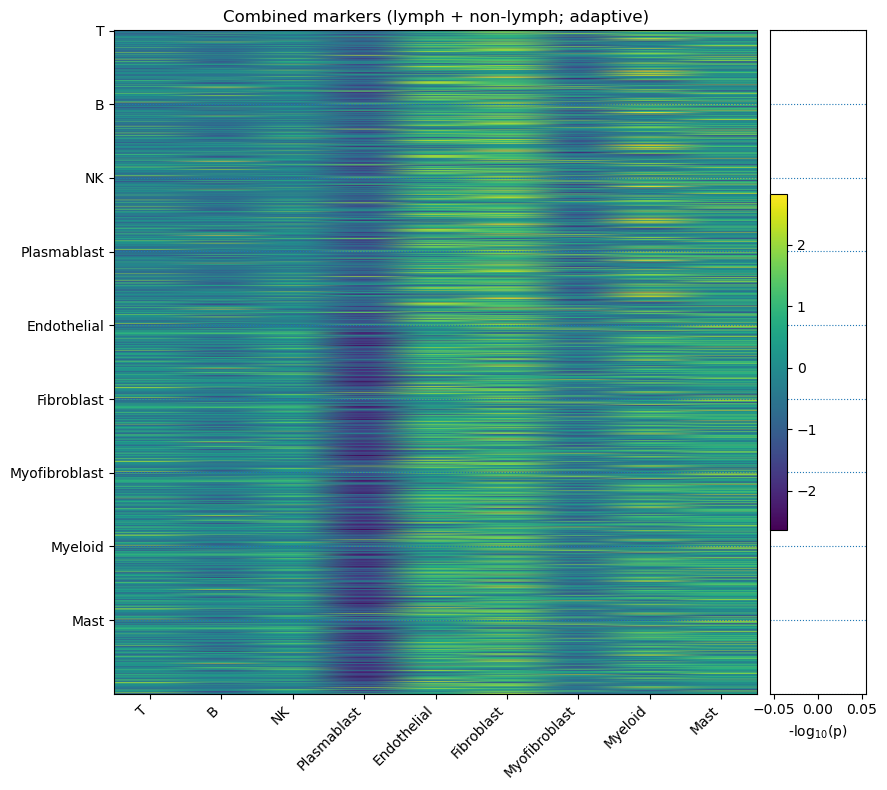

In [ ]:
# ---- 如果還沒定義 mean_by_ct，補一個簡潔版 ----
def mean_by_ct(pb: pd.DataFrame) -> pd.DataFrame:
    # pb: genes × (sample|CT)
    cts = [c.split("|",1)[1] for c in pb.columns]
    df = {}
    for ct in sorted(set(cts)):
        cols = [i for i,c in enumerate(cts) if c == ct]
        if cols:
            df[ct] = pb.iloc[:, cols].mean(axis=1)
    return pd.DataFrame(df)

# ---- 合併 marker：淋巴 + 非淋巴 ----
lymph_order = ["T","B","NK","Plasmablast"]
non_order   = ["Endothelial","Fibroblast","Myofibroblast","Myeloid","Mast"]
combined_order = lymph_order + non_order

# 1) 合併 gene 清單（取聯集），同時只保留存在於 pb_all 的基因
combined_markers = {}
genes_in_pb = set(pb_all.index.astype(str))
for ct in combined_order:
    g1 = set(markers_lymph.get(ct, []))
    g2 = set(markers_non.get(ct, []))
    gs = list((g1 | g2) & genes_in_pb)
    combined_markers[ct] = sorted(gs)

# （可選）限制每個 CT 顯示的基因數，避免圖太擠
# 若你想依統計分數來篩 top-N，會用到下一段合併好的 stats_all
TOP_N_PER_CT = None  # 例如 80；不想限制就設 None

# 2) 合併統計表，優先使用 q-value，沒有 q 就用 p
def _prepare_stats_df(stats):
    if stats is None or len(stats)==0:
        return pd.DataFrame(columns=["gene","ct","score","p","q"])
    cols = {c.lower(): c for c in stats.columns}
    out = stats.rename(columns={cols.get("gene","gene"): "gene",
                                cols.get("ct","ct"): "ct",
                                cols.get("score","score"): "score",
                                cols.get("p","p"): "p",
                                cols.get("q","q"): "q"}).copy()
    # 確保有需要的欄
    for need in ["gene","ct","score","p","q"]:
        if need not in out.columns:
            out[need] = np.nan
    out["gene"] = out["gene"].astype(str)
    out["ct"]   = out["ct"].astype(str)
    return out[["gene","ct","score","p","q"]]

stats_L = _prepare_stats_df(stats_lymph)
stats_N = _prepare_stats_df(stats_non)
stats_all = pd.concat([stats_L, stats_N], axis=0, ignore_index=True).drop_duplicates(subset=["gene","ct"], keep="first")

# 3) 做 p 值矩陣（genes×CT），以 q 為主、沒有 q 就用 p
# 先選擇一個 "p_like" 欄：q 優先，否則 p
stats_all["p_like"] = stats_all["q"].where(stats_all["q"].notna(), stats_all["p"])
# 只保留我們要畫的 CT 與存在 pb 的基因
stats_all = stats_all[stats_all["ct"].isin(combined_order)]
stats_all = stats_all[stats_all["gene"].isin(genes_in_pb)]

# pivot 成 genes×CT
pval_df = stats_all.pivot_table(index="gene", columns="ct", values="p_like", aggfunc="min")

# 4) 依分數（每個 CT 的 score）做排序 & 取 top-N（若指定 TOP_N_PER_CT）
if TOP_N_PER_CT is not None:
    # 先把分數表轉成方便的查詢字典：{ct: {gene: score}}
    score_map = (stats_all.dropna(subset=["score"])
                          .groupby("ct")
                          .apply(lambda d: dict(zip(d["gene"], d["score"])))
                          .to_dict())
    for ct in combined_order:
        gs = combined_markers.get(ct, [])
        if not gs:
            continue
        if ct in score_map:
            # 按 score 由高到低排序取前 N
            gs_sorted = sorted(gs, key=lambda g: score_map[ct].get(g, -np.inf), reverse=True)
            combined_markers[ct] = gs_sorted[:TOP_N_PER_CT]
        else:
            combined_markers[ct] = gs[:TOP_N_PER_CT]

# 5) 檢查每個 CT 的 marker 數
print("Marker counts per CT (combined):")
for ct in combined_order:
    print(f"  {ct:13s}: {len(combined_markers[ct])}")

# 6) 一張總 heatmap（右側條為 -log10 p_like）
plot_marker_heatmap(
    pb_all,
    combined_markers,
    combined_order,
    title="Combined markers (lymph + non-lymph; adaptive)",
    show_pbars=True,
    pval_df=pval_df
)


In [274]:
plot_from_union_markerlist(pb_all,
                           combined_markers,
                           combined_order,
                           title="Global per-CT markers (union → per-CT assignment)")

[Global per-CT markers (union → per-CT assignment)] 沒有可用的 marker 可畫。
